# Output-attending (OA) heads in real ICL tasks

**OI heads**: attend from output positions → input positions (enrich output representations)
**OA heads**: attend from final position (arrow) → output positions (aggregate enriched representations)

Proposed circuit: OI heads enrich output positions → OA heads read enriched outputs and write to final position.


In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd, pickle
from collections import defaultdict
from tqdm import tqdm
from transformer_lens import HookedTransformer

try:
    from configs import MODEL_NAME
except ImportError:
    MODEL_NAME = 'meta-llama/Llama-3.2-3B'

%matplotlib inline
sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-01 16:23:24.172870: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:02<00:00,  1.01s/it]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


In [2]:
def build_icl_prompt(demo_pairs, query_input):
    lines = [f'{inp} → {out}' for inp, out in demo_pairs]
    lines.append(f'{query_input} →')
    return '\n'.join(lines)

def find_per_demo_positions(model, prompt, demos):
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    full_decoded = model.tokenizer.decode(tokens)
    char_to_tok = []
    for i in range(len(tokens)):
        s = model.tokenizer.decode([tokens[i].item()])
        char_to_tok.extend([i] * len(s))

    def span_to_toks(start, end):
        if start < 0 or end > len(char_to_tok): return []
        return sorted(set(char_to_tok[start:end]))

    result = []
    search_from = 0
    for inp, out in demos:
        demo = {'input_positions': [], 'output_positions': []}
        inp_s, out_s = str(inp), str(out)
        idx = full_decoded.find(inp_s, search_from)
        if idx >= 0:
            demo['input_positions'] = span_to_toks(idx, idx + len(inp_s))
            search_from = idx + len(inp_s)
        arrow = full_decoded.find('→', search_from)
        if arrow >= 0:
            oidx = full_decoded.find(out_s, arrow)
            if oidx >= 0:
                demo['output_positions'] = span_to_toks(oidx, oidx + len(out_s))
                search_from = oidx + len(out_s)
        result.append(demo)
    return result

@torch.no_grad()
def check_correct_multitoken(model, tokens, expected, max_new_tokens=20, hooks=None):
    target = expected.strip()
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = model.tokenizer.decode(generated).strip()
        if decoded == target:
            return 1
        if len(decoded) >= len(target):
            return 0
        if decoded and not target.startswith(decoded):
            return 0
    return int(model.tokenizer.decode(generated).strip() == target)

def heads_by_layer(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(hbl):
    hooks = []
    for L, h_list in hbl.items():
        def hook(z, hook, _hl=h_list):
            for h in _hl: z[0, :, h, :] = 0
            return z
        hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return hooks

top10pct_n = max(1, int(0.10 * n_layers * n_heads))
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]

In [3]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length, rng):
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(rng.choice(p) for p in pattern[:length])

def _gen_nonce(rng, transform_fn, word_len=5):
    words = []
    while len(set(words)) < 11:
        words = [make_nonsense(word_len, rng) for _ in range(11)]
    demo_pairs = [(w, transform_fn(w)) for w in words[:10]]
    qi = words[10]
    return demo_pairs, qi, transform_fn(qi)

def gen_repetition(rng):    return _gen_nonce(rng, lambda x: x + x)
def gen_prepend_first(rng): return _gen_nonce(rng, lambda x: x[0] + x)
def gen_append_last(rng):   return _gen_nonce(rng, lambda x: x + x[-1])
def gen_drop_first(rng):    return _gen_nonce(rng, lambda x: x[1:])
def gen_drop_last(rng):     return _gen_nonce(rng, lambda x: x[:-1])
def gen_reverse(rng):       return _gen_nonce(rng, lambda x: x[::-1])
def gen_swap_ends(rng):     return _gen_nonce(rng, lambda x: x[-1] + x[1:-1] + x[0])
def gen_rotate_left(rng):   return _gen_nonce(rng, lambda x: x[1:] + x[0])
def gen_suffix_ed(rng):     return _gen_nonce(rng, lambda x: x + 'ed')
def gen_double_vowels(rng):
    return _gen_nonce(rng, lambda x: ''.join(c * 2 if c in VOWELS else c for c in x))

def _gen_arith(rng, fn, lo, hi):
    pool = list(range(lo, hi + 1))
    rng.shuffle(pool)
    nums = pool[:11]
    demo_pairs = [(str(n), str(fn(n))) for n in nums[:10]]
    qi = str(nums[10])
    return demo_pairs, qi, str(fn(nums[10]))

def gen_add_3(rng):       return _gen_arith(rng, lambda x: x + 3, 1, 50)
def gen_add_7(rng):       return _gen_arith(rng, lambda x: x + 7, 1, 50)
def gen_add_13(rng):      return _gen_arith(rng, lambda x: x + 13, 1, 50)
def gen_mul_2(rng):       return _gen_arith(rng, lambda x: 2*x, 1, 50)
def gen_mul_3(rng):       return _gen_arith(rng, lambda x: 3*x, 1, 30)
def gen_mul_5(rng):       return _gen_arith(rng, lambda x: 5*x, 1, 20)
def gen_mul_10(rng):      return _gen_arith(rng, lambda x: 10*x, 1, 20)
def gen_mul_2_add_1(rng): return _gen_arith(rng, lambda x: 2*x + 1, 1, 50)
def gen_mul_3_add_2(rng): return _gen_arith(rng, lambda x: 3*x + 2, 1, 30)
def gen_mul_2_sub_1(rng): return _gen_arith(rng, lambda x: 2*x - 1, 1, 50)

TASK_GENERATORS = {
    'repetition': gen_repetition, 'prepend_first': gen_prepend_first,
    'append_last': gen_append_last, 'drop_first': gen_drop_first,
    'drop_last': gen_drop_last, 'reverse': gen_reverse,
    'swap_ends': gen_swap_ends, 'rotate_left': gen_rotate_left,
    'suffix_ed': gen_suffix_ed, 'double_vowels': gen_double_vowels,
    'add_3': gen_add_3, 'add_7': gen_add_7, 'add_13': gen_add_13,
    'mul_2': gen_mul_2, 'mul_3': gen_mul_3, 'mul_5': gen_mul_5,
    'mul_10': gen_mul_10, 'mul_2_add_1': gen_mul_2_add_1,
    'mul_3_add_2': gen_mul_3_add_2, 'mul_2_sub_1': gen_mul_2_sub_1,
}
TASK_NAMES = list(TASK_GENERATORS.keys())
NONCE_TASKS = TASK_NAMES[:10]
ARITH_TASKS = TASK_NAMES[10:]
print(f'{len(NONCE_TASKS)} nonce tasks, {len(ARITH_TASKS)} arithmetic tasks')

10 nonce tasks, 10 arithmetic tasks


In [4]:
import os, pickle
SAVE_PATH = 'filtered_prompts.pkl'

if os.path.exists(SAVE_PATH):
    print(f'Loading filtered prompts from {SAVE_PATH}...')
    with open(SAVE_PATH, 'rb') as f:
        saved = pickle.load(f)
    TASKS = saved['TASKS']
    TASK_NAMES_ACTIVE = saved['TASK_NAMES_ACTIVE']
    print(f'Loaded {len(TASK_NAMES_ACTIVE)} active tasks')
    for name in TASK_NAMES_ACTIVE:
        print(f'  {name:<18s} n={len(TASKS[name])}')
else:
    raise FileNotFoundError('Run icl_tasks_v2.ipynb first to generate filtered_prompts.pkl')

nonce_active = [n for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE]
arith_active = [n for n in ARITH_TASKS if n in TASK_NAMES_ACTIVE]
n_t = len(TASK_NAMES_ACTIVE)
n_cols = 4
n_rows = int(np.ceil(n_t / n_cols))

Loading filtered prompts from filtered_prompts.pkl...
Loaded 20 active tasks
  repetition         n=50
  prepend_first      n=50
  append_last        n=50
  drop_first         n=50
  drop_last          n=50
  reverse            n=12
  swap_ends          n=13
  rotate_left        n=42
  suffix_ed          n=50
  double_vowels      n=50
  add_3              n=50
  add_7              n=50
  add_13             n=50
  mul_2              n=50
  mul_3              n=50
  mul_5              n=50
  mul_10             n=50
  mul_2_add_1        n=50
  mul_3_add_2        n=35
  mul_2_sub_1        n=50


## OI head scoring (output → input)

Same as icl_tasks_v2: attention from output positions to input positions, baseline-subtracted.

In [5]:
def score_oi_heads(prompts_data, desc='OI Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_in)
        for q in range(seq_len):
            if q in all_out: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1)

print('Scoring OI heads per task...')
task_oi_scores = {}
for name in TASK_NAMES_ACTIVE:
    task_oi_scores[name] = score_oi_heads(TASKS[name], desc=name)

# Select top 10% per task
task_oi_top = {}
for name in TASK_NAMES_ACTIVE:
    sc = task_oi_scores[name]
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    task_oi_top[name] = [(L, h) for L, h, _ in flat[:top10pct_n]]

print('OI scoring complete')

Scoring OI heads per task...


OI scoring complete


## OA head scoring (final position → output)

Attention from the final position (arrow token) to demo output positions, baseline-subtracted
against attention from final position to demo input positions.


In [6]:
def score_oa_heads(prompts_data, desc='OA Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        last_pos = seq_len - 1
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        out_idx = sorted(all_out)
        in_idx  = sorted(all_in)
        if not out_idx or not in_idx: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            row = patt[:, last_pos, :]
            num_sum[L]  += row[:, out_idx].sum(dim=1).numpy() / len(out_idx)
            base_sum[L] += row[:, in_idx].sum(dim=1).numpy() / len(in_idx)
        cnt += 1
        del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1)

print('Scoring OA heads per task...')
task_oa_scores = {}
for name in TASK_NAMES_ACTIVE:
    task_oa_scores[name] = score_oa_heads(TASKS[name], desc=name)

# Select top 10% per task
task_oa_top = {}
for name in TASK_NAMES_ACTIVE:
    sc = task_oa_scores[name]
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    task_oa_top[name] = [(L, h) for L, h, _ in flat[:top10pct_n]]

print('OA scoring complete')

Scoring OA heads per task...


OA scoring complete


## OI vs OA score heatmaps per task

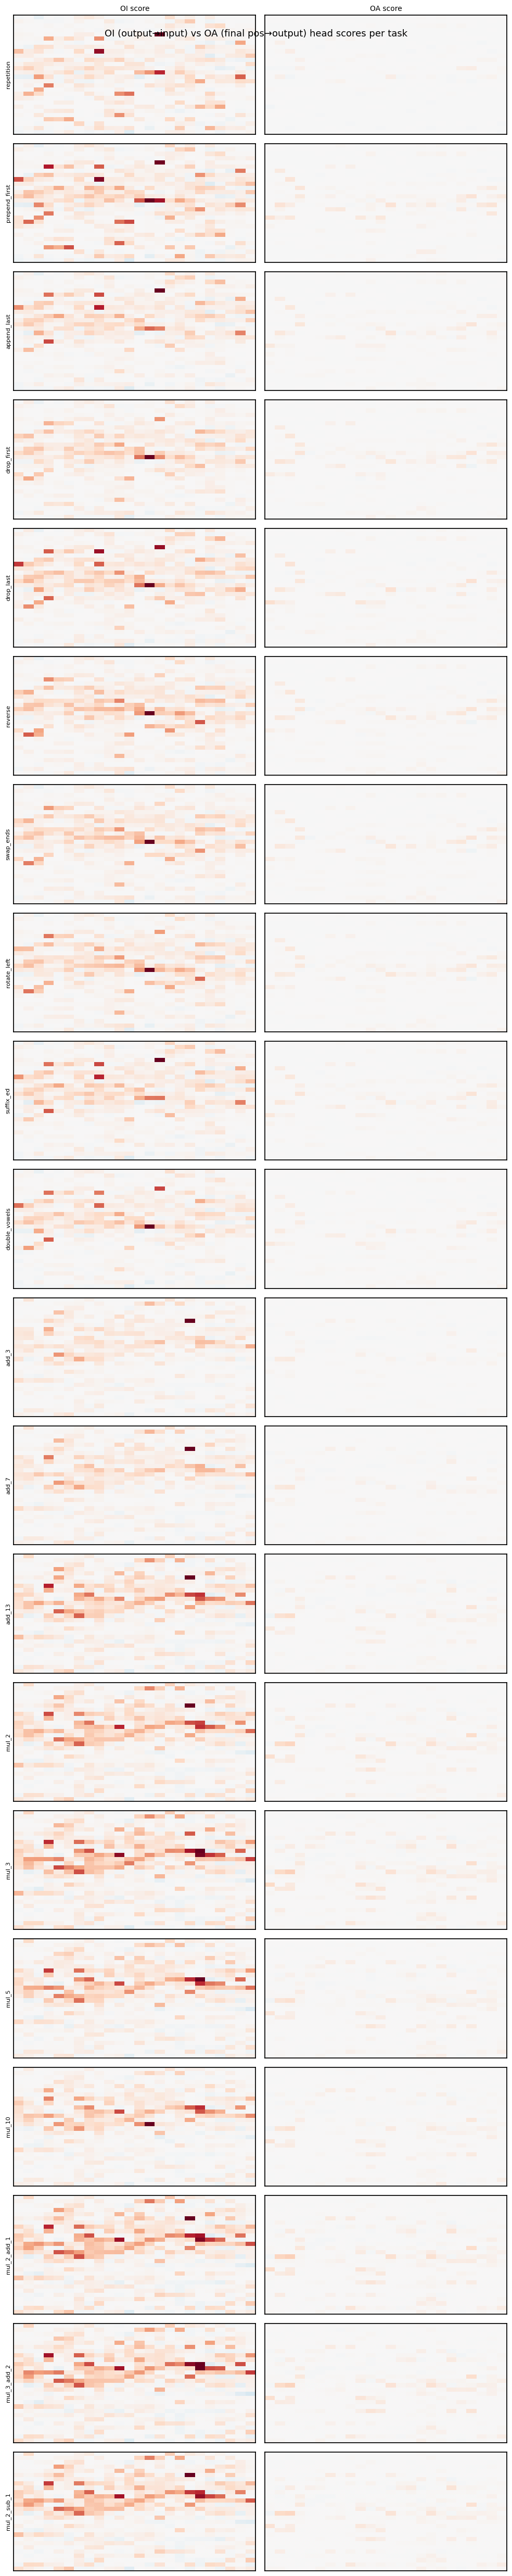

In [7]:
fig, axes = plt.subplots(n_t, 2, figsize=(10, 2.5 * n_t))
for i, name in enumerate(TASK_NAMES_ACTIVE):
    oi = task_oi_scores[name]
    oa = task_oa_scores[name]
    vmax = max(np.abs(oi).max(), np.abs(oa).max())
    axes[i, 0].imshow(oi, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[i, 0].set_ylabel(name, fontsize=8)
    if i == 0: axes[i, 0].set_title('OI score', fontsize=10)
    axes[i, 1].imshow(oa, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    if i == 0: axes[i, 1].set_title('OA score', fontsize=10)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('OI (output→input) vs OA (final pos→output) head scores per task', fontsize=13)
plt.tight_layout(); plt.show()

## OA vs OI head overlap

Task                OA∩OI  OA only  OI only  Jaccard
----------------------------------------------
repetition              9       58       58    0.072
prepend_first          12       55       55    0.098
append_last            13       54       54    0.107
drop_first             15       52       52    0.126
drop_last              10       57       57    0.081
reverse                12       55       55    0.098
swap_ends               9       58       58    0.072
rotate_left            11       56       56    0.089
suffix_ed              11       56       56    0.089
double_vowels           9       58       58    0.072
add_3                   4       63       63    0.031
add_7                   5       62       62    0.039
add_13                  4       63       63    0.031
mul_2                   2       65       65    0.015
mul_3                   2       65       65    0.015
mul_5                   0       67       67    0.000
mul_10                  0       67       67    0.000

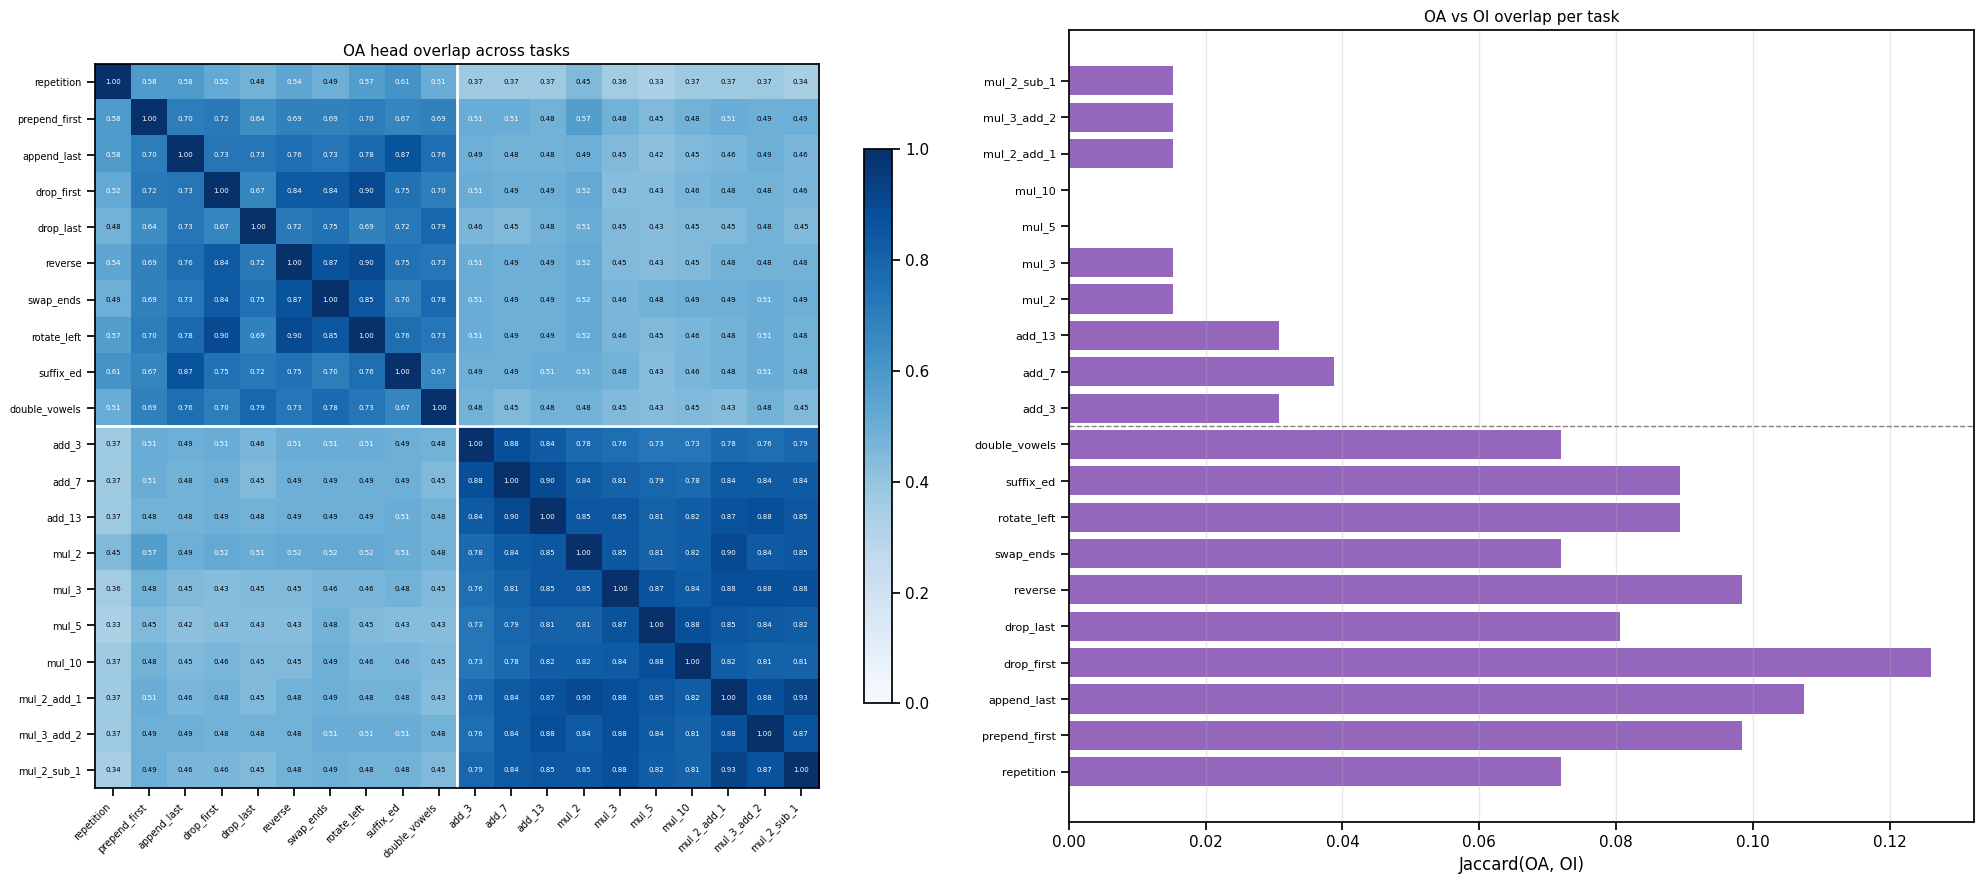

In [8]:
# Per-task overlap
print(f'{"Task":<18s} {"OA∩OI":>6s} {"OA only":>8s} {"OI only":>8s} {"Jaccard":>8s}')
print('-' * 46)
all_jaccards = []
for name in TASK_NAMES_ACTIVE:
    oa_set = set(task_oa_top[name])
    oi_set = set(task_oi_top[name])
    inter = len(oa_set & oi_set)
    union = len(oa_set | oi_set)
    j = inter / union if union > 0 else 0
    all_jaccards.append(j)
    print(f'{name:<18s} {inter:>6d} {len(oa_set - oi_set):>8d} {len(oi_set - oa_set):>8d} {j:>8.3f}')
print(f'\nMean Jaccard: {np.mean(all_jaccards):.3f}')

# Cross-task OA overlap matrix
nt = len(TASK_NAMES_ACTIVE)
oa_overlap = np.zeros((nt, nt))
for i, n1 in enumerate(TASK_NAMES_ACTIVE):
    for j, n2 in enumerate(TASK_NAMES_ACTIVE):
        s1 = set(task_oa_top[n1]); s2 = set(task_oa_top[n2])
        oa_overlap[i, j] = len(s1 & s2) / max(len(s1), 1)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# OA overlap
ax = axes[0]
im = ax.imshow(oa_overlap, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.7)
ax.set_xticks(range(nt)); ax.set_yticks(range(nt))
ax.set_xticklabels(TASK_NAMES_ACTIVE, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(TASK_NAMES_ACTIVE, fontsize=7)
for i in range(nt):
    for j in range(nt):
        ax.text(j, i, f'{oa_overlap[i,j]:.2f}', ha='center', va='center', fontsize=5,
                color='white' if oa_overlap[i,j] > 0.5 else 'black')
n_nonce_a = sum(1 for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE)
ax.axhline(n_nonce_a - 0.5, color='white', lw=2)
ax.axvline(n_nonce_a - 0.5, color='white', lw=2)
ax.set_title('OA head overlap across tasks', fontsize=11)

# OA vs OI per-task Jaccard
ax = axes[1]
ax.barh(range(nt), all_jaccards, color='tab:purple')
ax.set_yticks(range(nt))
ax.set_yticklabels(TASK_NAMES_ACTIVE, fontsize=8)
ax.set_xlabel('Jaccard(OA, OI)')
ax.set_title('OA vs OI overlap per task', fontsize=11)
ax.axhline(n_nonce_a - 0.5, color='gray', lw=1, ls='--')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

## Ablation: OA heads vs OI heads vs random

For each task, ablate top-10% OA heads, top-10% OI heads, and a size-matched random control.
Measure accuracy on orig prompts.

In [9]:
OA_ABL_KEYS = ['unablated', 'top10_oa', 'top10_oi', 'rand10']
oa_ablation_results = {name: {ab: [] for ab in OA_ABL_KEYS} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oa_set = set(task_oa_top[name])
    oi_set = set(task_oi_top[name])
    rng_r = random.Random(hash(name + '_oa') % 10**6)
    rand_set = rng_r.sample([p for p in all_pairs if p not in oa_set and p not in oi_set],
                             top10pct_n)
    hooks_map = {
        'unablated': [],
        'top10_oa': make_ablation_hooks(heads_by_layer(task_oa_top[name])),
        'top10_oi': make_ablation_hooks(heads_by_layer(task_oi_top[name])),
        'rand10':   make_ablation_hooks(heads_by_layer(rand_set)),
    }
    for pdata in tqdm(TASKS[name], desc=f'{name} ablation'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        for ab in OA_ABL_KEYS:
            h = hooks_map[ab] if hooks_map[ab] else None
            oa_ablation_results[name][ab].append(
                check_correct_multitoken(model, tokens, ans, hooks=h))
        torch.cuda.empty_cache()
    for ab in OA_ABL_KEYS:
        oa_ablation_results[name][ab] = np.array(oa_ablation_results[name][ab])

print('Ablation complete')

mul_2_sub_1 ablation: 100%|██████████| 50/50 [00:16<00:00,  3.02it/s]

Ablation complete


/tmp/ipykernel_134892/1812738672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
/tmp/ipykernel_134892/1812738672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
/tmp/ipykernel_134892/1812738672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
/tmp/ipykernel_134892/1812738672.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remov

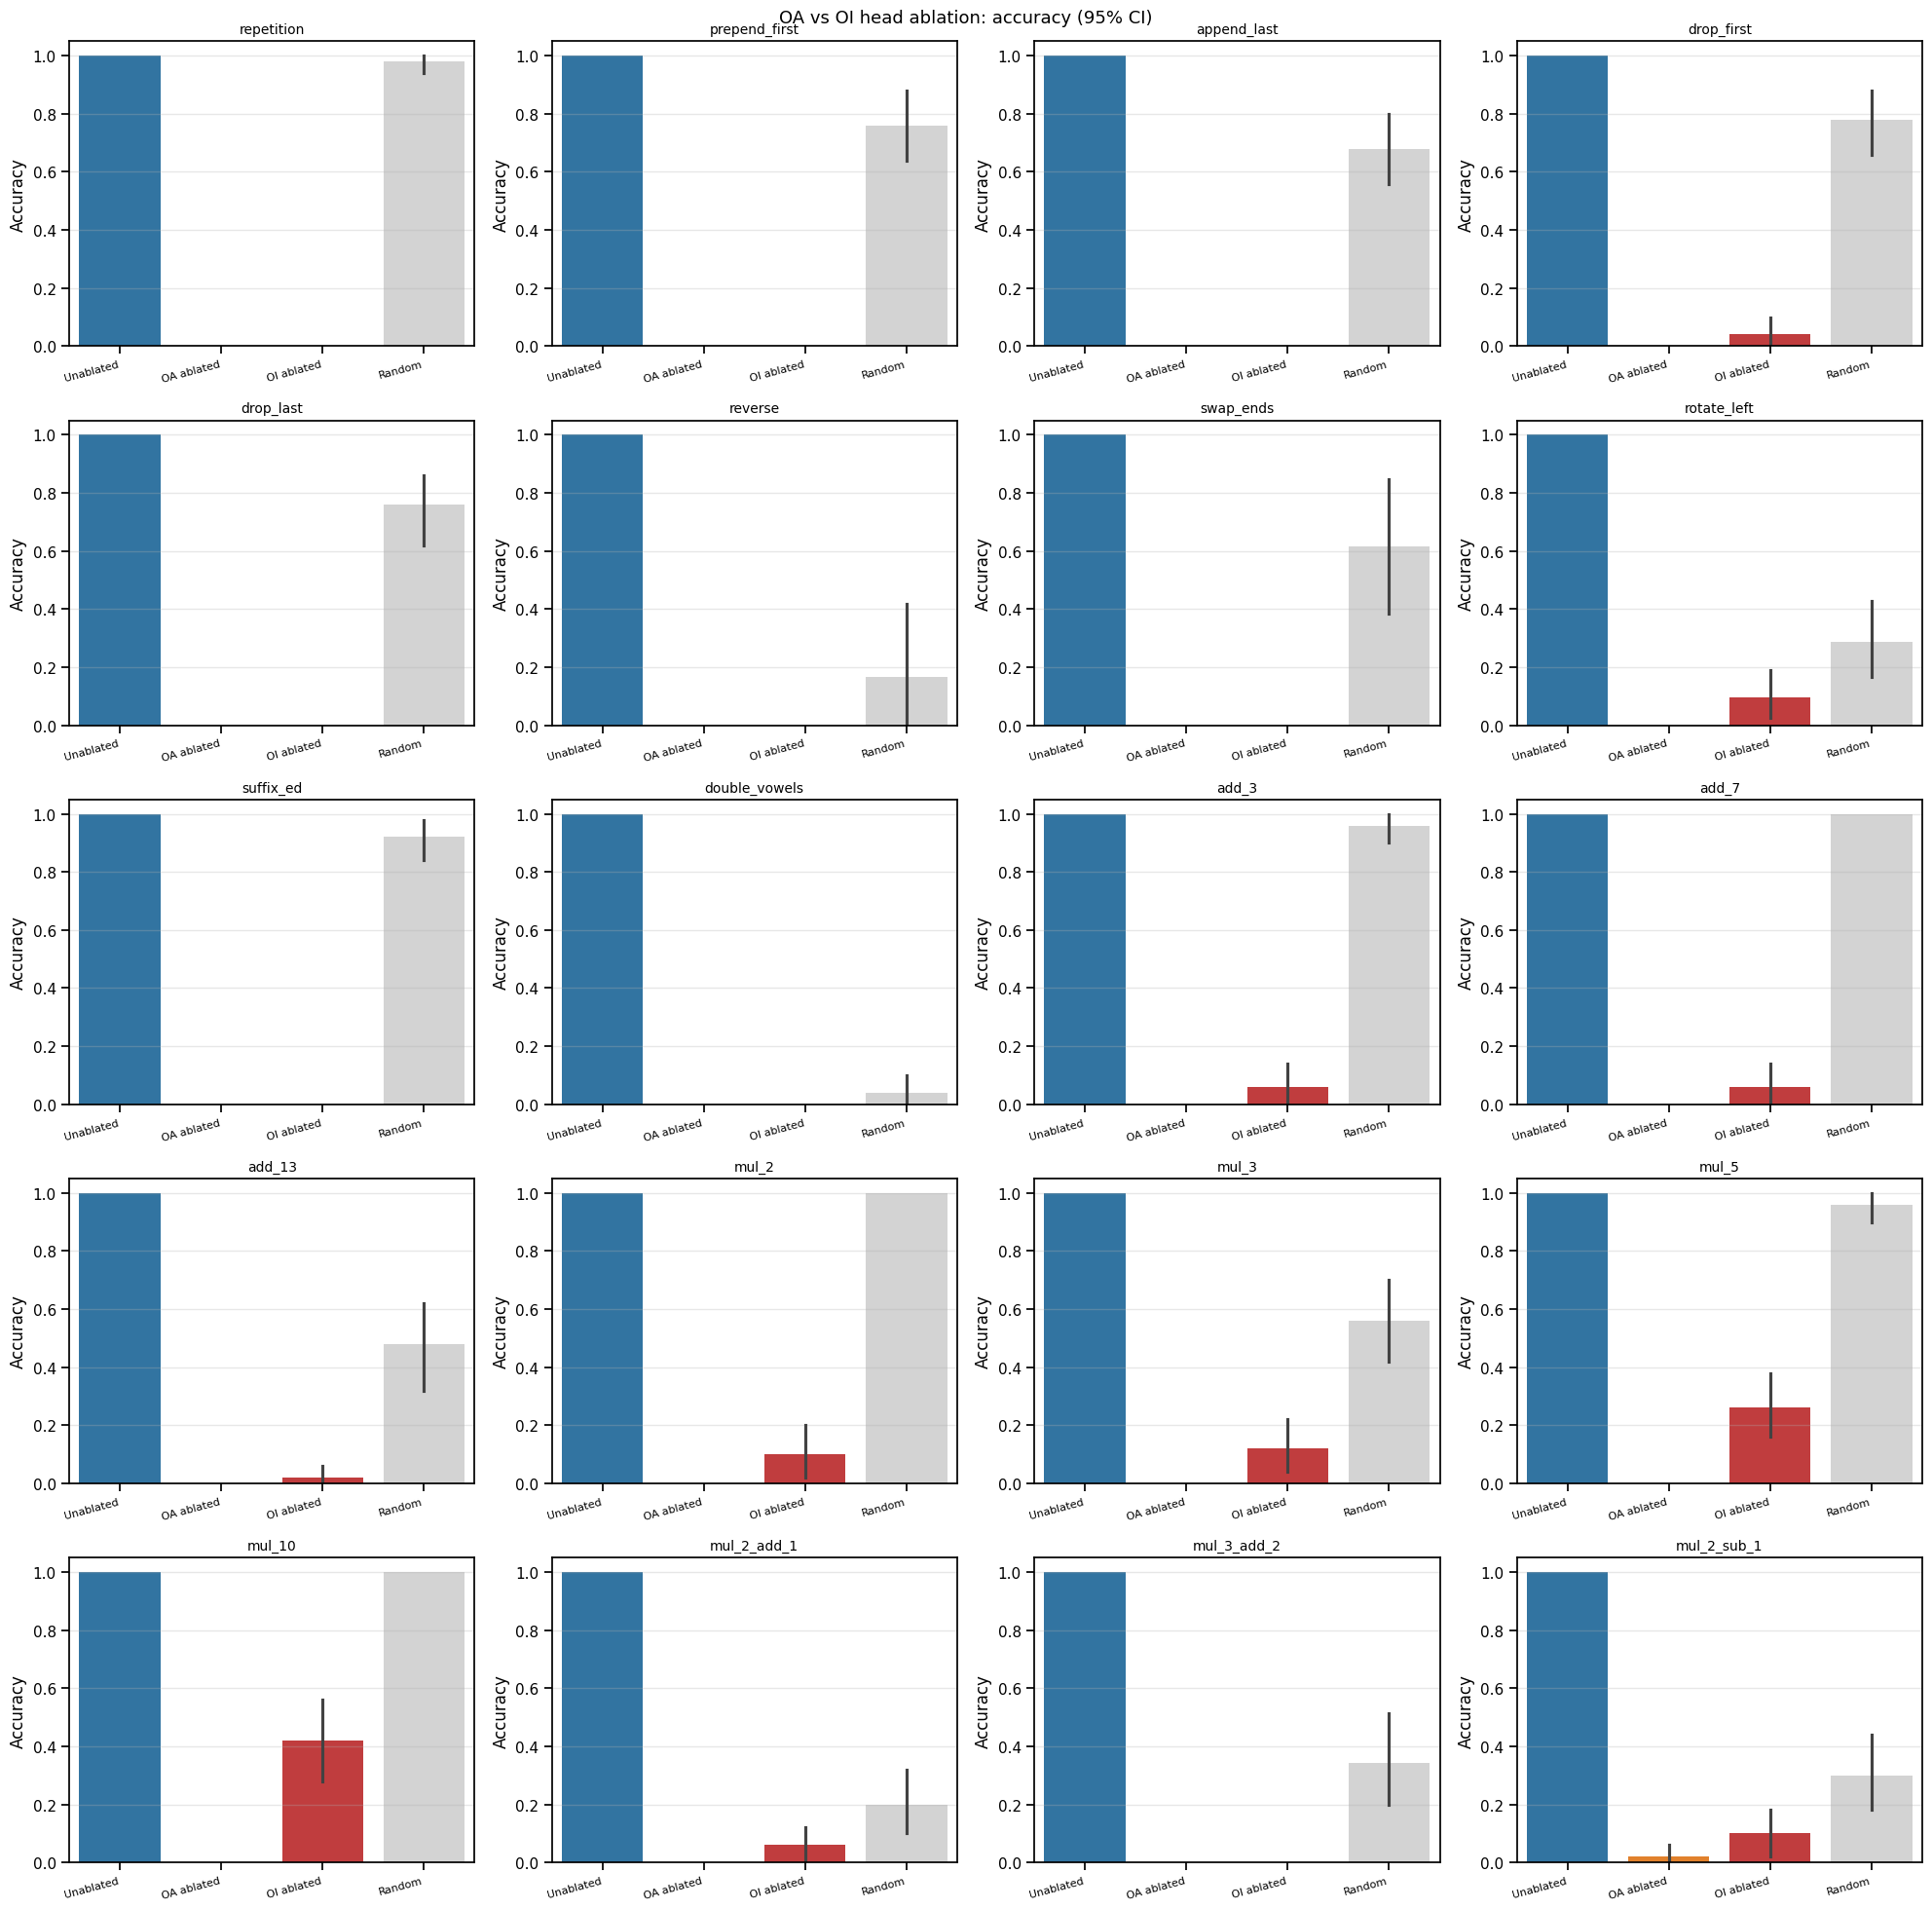

In [10]:
ab_label = {'unablated': 'Unablated', 'top10_oa': 'OA ablated',
            'top10_oi': 'OI ablated', 'rand10': 'Random'}
ab_order = [ab_label[k] for k in OA_ABL_KEYS]
ab_colors = {'Unablated': 'tab:blue', 'OA ablated': 'tab:orange',
             'OI ablated': 'tab:red', 'Random': 'lightgray'}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    rows = [{'Ablation': ab_label[ab], 'Accuracy': v}
            for ab in OA_ABL_KEYS for v in oa_ablation_results[name][ab]]
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
                palette=[ab_colors[a] for a in ab_order],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel(''); ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('OA vs OI head ablation: accuracy (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

/tmp/ipykernel_134892/1524493465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
/tmp/ipykernel_134892/1524493465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
/tmp/ipykernel_134892/1524493465.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,


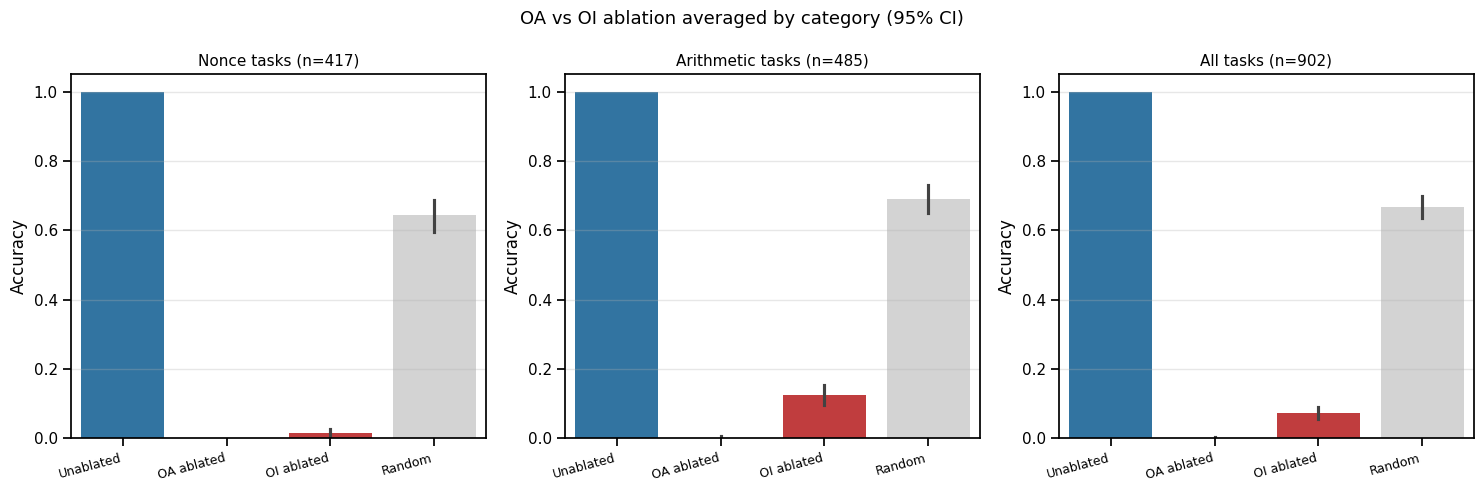

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    rows = []
    for ab in OA_ABL_KEYS:
        for name in task_list:
            for v in oa_ablation_results[name][ab]:
                rows.append({'Ablation': ab_label[ab], 'Accuracy': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order,
                palette=[ab_colors[a] for a in ab_order],
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel('')
    ax.set_title(f'{group_label} (n={sum(len(TASKS[n]) for n in task_list)})', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
fig.suptitle('OA vs OI ablation averaged by category (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

## Per-head OI vs OA score scatter

OI = output→input attention. OA = final position→output attention.

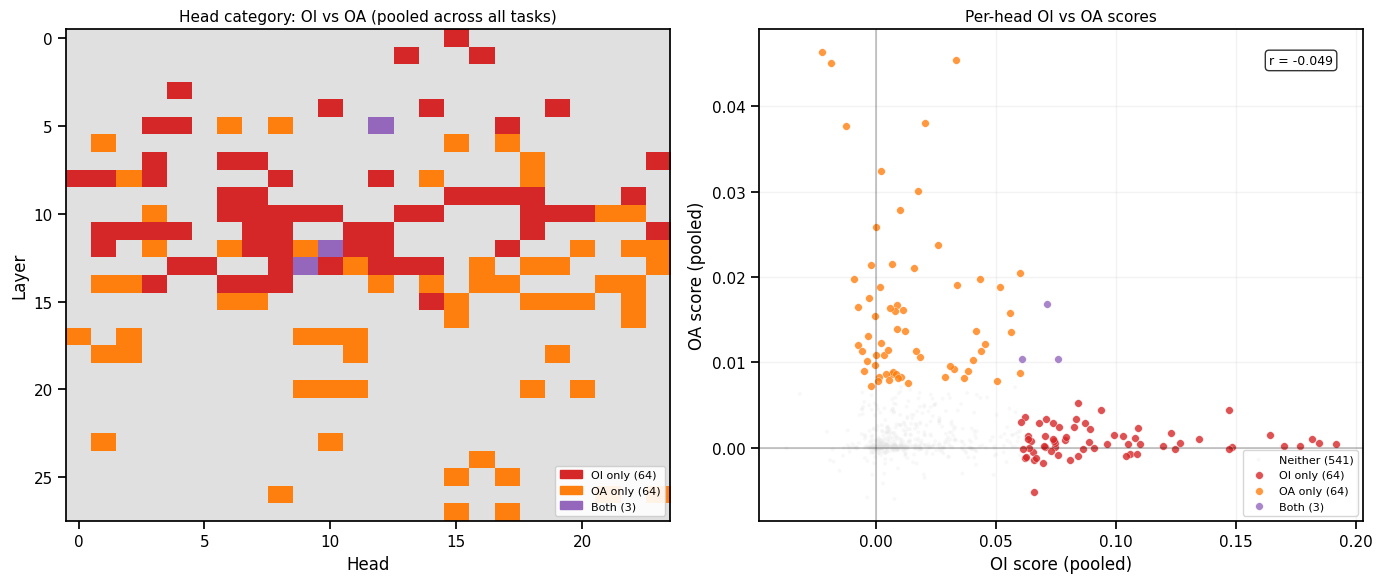

In [12]:
from matplotlib.patches import Patch

# Pool scores across all tasks
oi_pooled = np.mean([task_oi_scores[n] for n in TASK_NAMES_ACTIVE], axis=0)
oa_pooled = np.mean([task_oa_scores[n] for n in TASK_NAMES_ACTIVE], axis=0)

# Categorize by top-10% of pooled
oi_flat = sorted([(L, h, oi_pooled[L, h]) for L in range(n_layers) for h in range(n_heads)],
                 key=lambda x: -x[2])
oa_flat = sorted([(L, h, oa_pooled[L, h]) for L in range(n_layers) for h in range(n_heads)],
                 key=lambda x: -x[2])
H_oi_pooled = set((L, h) for L, h, _ in oi_flat[:top10pct_n])
H_oa_pooled = set((L, h) for L, h, _ in oa_flat[:top10pct_n])

cat_map = {}
for L in range(n_layers):
    for h in range(n_heads):
        p = (L, h)
        in_oi = p in H_oi_pooled
        in_oa = p in H_oa_pooled
        if in_oi and in_oa:   cat_map[p] = 'Both'
        elif in_oi:           cat_map[p] = 'OI only'
        elif in_oa:           cat_map[p] = 'OA only'
        else:                 cat_map[p] = 'Neither'

cat_colors = {'Neither': '#e0e0e0', 'OI only': 'tab:red', 'OA only': 'tab:orange', 'Both': 'tab:purple'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
from matplotlib.colors import ListedColormap, BoundaryNorm

# Left: category map
ax = axes[0]
cat_to_int = {'Neither': 0, 'OI only': 1, 'OA only': 2, 'Both': 3}
grid = np.zeros((n_layers, n_heads))
for (L, h), cat in cat_map.items():
    grid[L, h] = cat_to_int[cat]
cmap = ListedColormap([cat_colors[c] for c in ['Neither', 'OI only', 'OA only', 'Both']])
norm = BoundaryNorm(np.arange(-0.5, 4), cmap.N)
ax.imshow(grid, aspect='auto', cmap=cmap, norm=norm)
ax.set_xlabel('Head'); ax.set_ylabel('Layer')
ax.set_title('Head category: OI vs OA (pooled across all tasks)', fontsize=11)
counts = {c: sum(1 for v in cat_map.values() if v == c) for c in ['OI only', 'OA only', 'Both']}
ax.legend(handles=[Patch(color=cat_colors[c], label=f'{c} ({counts[c]})')
                   for c in ['OI only', 'OA only', 'Both']],
          fontsize=8, loc='lower right', framealpha=0.9)

# Right: scatter
ax = axes[1]
for cat in ['Neither', 'OI only', 'OA only', 'Both']:
    xs = [oi_pooled[L, h] for L in range(n_layers) for h in range(n_heads) if cat_map[(L, h)] == cat]
    ys = [oa_pooled[L, h] for L in range(n_layers) for h in range(n_heads) if cat_map[(L, h)] == cat]
    s = 8 if cat == 'Neither' else 30
    a = 0.2 if cat == 'Neither' else 0.8
    z = 1 if cat == 'Neither' else 2
    ax.scatter(xs, ys, c=cat_colors[cat], s=s, alpha=a, zorder=z,
               edgecolors='white' if cat != 'Neither' else 'none', linewidths=0.3,
               label=f'{cat} ({counts.get(cat, len(xs))})')
ax.set_xlabel('OI score (pooled)'); ax.set_ylabel('OA score (pooled)')
ax.set_title('Per-head OI vs OA scores', fontsize=11)
ax.axhline(0, color='black', lw=0.3); ax.axvline(0, color='black', lw=0.3)
ax.legend(fontsize=8); ax.grid(True, alpha=0.15)

r = np.corrcoef(oi_pooled.flatten(), oa_pooled.flatten())[0, 1]
ax.text(0.95, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=9,
        ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout(); plt.show()

In [13]:
print('Layer distribution of pooled head categories:')
for cat in ['OI only', 'OA only', 'Both']:
    layers = [L for (L, h), c in cat_map.items() if c == cat]
    if layers:
        print(f'  {cat:<10s}: {len(layers)} heads, layers {min(layers)}-{max(layers)}, '
              f'mean={np.mean(layers):.1f}')

Layer distribution of pooled head categories:
  OI only   : 64 heads, layers 0-15, mean=9.5
  OA only   : 64 heads, layers 5-27, mean=15.4
  Both      : 3 heads, layers 5-13, mean=10.0


## Causal connectivity: do OA heads depend on OI heads?

Ablate OI heads and measure whether OA heads still attend to output positions.
If OI heads enrich output positions and OA heads read that enrichment, killing OI heads should reduce OA attention to outputs.

In [17]:
# === Connectivity with random ablation control ===

oa_attn_connectivity = {name: {'intact': [], 'oi_ablated': [], 'rand_ablated': []}
                         for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oi_hooks = make_ablation_hooks(heads_by_layer(task_oi_top[name]))

    # Random control: same size, excluding OI and OA heads
    oi_set = set(task_oi_top[name])
    oa_set = set(task_oa_top[name])
    rng_r = random.Random(hash(name + '_conn') % 10**6)
    rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set and p not in oa_set],
                               top10pct_n)
    rand_hooks = make_ablation_hooks(heads_by_layer(rand_heads))

    oa_layers_needed = sorted(set(L for L, h in task_oa_top[name]))

    for pdata in tqdm(TASKS[name], desc=f'{name} connectivity'):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        last_pos = seq_len - 1
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        out_idx = sorted(set(p for d in per_demo for p in d.get('output_positions', [])))
        if not out_idx: continue

        # Intact
        with torch.no_grad():
            _, cache_intact = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        intact_attn = []
        for L, h in task_oa_top[name]:
            row = cache_intact['pattern', L][0, h, last_pos, :]
            intact_attn.append(row[out_idx].sum().item())
        oa_attn_connectivity[name]['intact'].append(np.mean(intact_attn))
        del cache_intact

        # Helper to measure OA attention under ablation
        def measure_under_ablation(abl_hooks):
            pattern_cache = {}
            def make_cacher(layer):
                def hook_fn(pattern, hook):
                    pattern_cache[layer] = pattern.detach().cpu().float()
                    return pattern
                return hook_fn
            hooks = list(abl_hooks)
            for L in oa_layers_needed:
                hooks.append((f'blocks.{L}.attn.hook_pattern', make_cacher(L)))
            with torch.no_grad():
                model.run_with_hooks(tokens, fwd_hooks=hooks)
            attn_vals = []
            for L, h in task_oa_top[name]:
                row = pattern_cache[L][0, h, last_pos, :]
                attn_vals.append(row[out_idx].sum().item())
            return np.mean(attn_vals)

        oa_attn_connectivity[name]['oi_ablated'].append(measure_under_ablation(oi_hooks))
        oa_attn_connectivity[name]['rand_ablated'].append(measure_under_ablation(rand_hooks))
        torch.cuda.empty_cache()

print('Connectivity test complete')

mul_2_sub_1 connectivity: 100%|██████████| 50/50 [00:06<00:00,  7.31it/s]

Connectivity test complete


/tmp/ipykernel_134892/3779834822.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='OA attn to outputs',
/tmp/ipykernel_134892/3779834822.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='OA attn to outputs',
/tmp/ipykernel_134892/3779834822.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='OA attn to outputs',


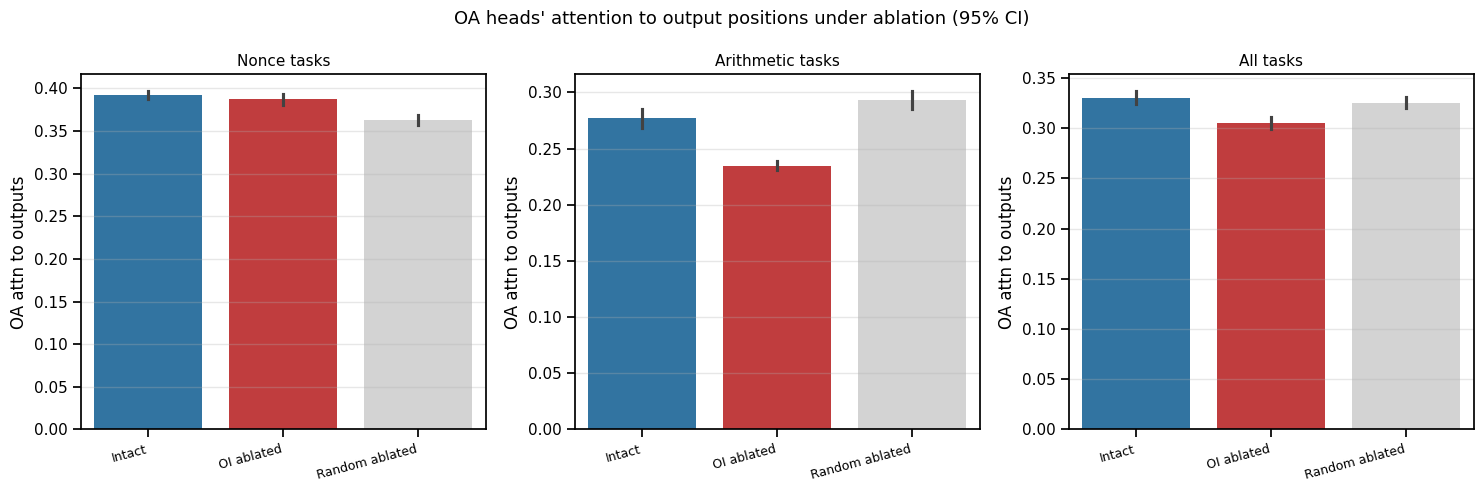


Task                 Intact   OI abl  Rand abl  OI drop  Rand drop
------------------------------------------------------------
repetition           0.3294   0.3660    0.3356  -0.0367    -0.0062
prepend_first        0.4674   0.5083    0.4446  -0.0409    +0.0228
append_last          0.3657   0.3528    0.3589  +0.0129    +0.0067
drop_first           0.4070   0.3194    0.3580  +0.0876    +0.0490
drop_last            0.3394   0.3900    0.2684  -0.0506    +0.0710
reverse              0.3796   0.3509    0.3709  +0.0286    +0.0087
swap_ends            0.3882   0.4231    0.3786  -0.0349    +0.0096
rotate_left          0.4182   0.3302    0.3816  +0.0880    +0.0366
suffix_ed            0.3821   0.3437    0.3047  +0.0383    +0.0774
double_vowels        0.4308   0.4747    0.4447  -0.0439    -0.0139
add_3                0.2014   0.2483    0.2199  -0.0469    -0.0185
add_7                0.2369   0.2266    0.1904  +0.0102    +0.0464
add_13               0.2404   0.2227    0.3221  +0.0177    -0.0816


In [18]:
# === Plot with control ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    rows = []
    for name in task_list:
        for v in oa_attn_connectivity[name]['intact']:
            rows.append({'Condition': 'Intact', 'OA attn to outputs': v})
        for v in oa_attn_connectivity[name]['oi_ablated']:
            rows.append({'Condition': 'OI ablated', 'OA attn to outputs': v})
        for v in oa_attn_connectivity[name]['rand_ablated']:
            rows.append({'Condition': 'Random ablated', 'OA attn to outputs': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Condition', y='OA attn to outputs',
                order=['Intact', 'OI ablated', 'Random ablated'],
                palette={'Intact': 'tab:blue', 'OI ablated': 'tab:red',
                         'Random ablated': 'lightgray'},
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_title(f'{group_label}', fontsize=11)
    ax.set_xlabel(''); ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)
fig.suptitle("OA heads' attention to output positions under ablation (95% CI)", fontsize=13)
plt.tight_layout(); plt.show()

# Summary
print(f'\n{"Task":<18s} {"Intact":>8s} {"OI abl":>8s} {"Rand abl":>9s} {"OI drop":>8s} {"Rand drop":>10s}')
print('-' * 60)
for name in TASK_NAMES_ACTIVE:
    intact = np.mean(oa_attn_connectivity[name]['intact'])
    oi_abl = np.mean(oa_attn_connectivity[name]['oi_ablated'])
    rand_abl = np.mean(oa_attn_connectivity[name]['rand_ablated'])
    print(f'{name:<18s} {intact:>8.4f} {oi_abl:>8.4f} {rand_abl:>9.4f} '
          f'{intact - oi_abl:>+8.4f} {intact - rand_abl:>+10.4f}')

In [20]:
# === OA output vectors: intact vs OI-ablated vs random-ablated ===

oa_output_cos = {name: {'oi_ablated': [], 'rand_ablated': []} for name in TASK_NAMES_ACTIVE}

Z_FILTER = lambda name: 'attn.hook_z' in name

for name in TASK_NAMES_ACTIVE:
    oi_hooks = make_ablation_hooks(heads_by_layer(task_oi_top[name]))

    oi_set = set(task_oi_top[name])
    oa_set = set(task_oa_top[name])
    rng_r = random.Random(hash(name + '_oavec') % 10**6)
    rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set and p not in oa_set],
                               top10pct_n)
    rand_hooks = make_ablation_hooks(heads_by_layer(rand_heads))

    oa_layers_needed = sorted(set(L for L, h in task_oa_top[name]))

    for pdata in tqdm(TASKS[name], desc=f'{name} OA output'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        last_pos = tokens.shape[1] - 1

        # Intact: cache z at final position for OA heads
        with torch.no_grad():
            _, cache_intact = model.run_with_cache(tokens, names_filter=Z_FILTER)
        intact_vecs = []
        for L, h in task_oa_top[name]:
            intact_vecs.append(cache_intact[f'blocks.{L}.attn.hook_z'][0, last_pos, h].cpu().float())
        intact_cat = torch.cat(intact_vecs)
        del cache_intact

        # Helper: get OA output vectors under ablation
        def get_oa_outputs_under_ablation(abl_hooks):
            z_cache = {}
            def make_z_cacher(layer):
                def hook_fn(z, hook):
                    z_cache[layer] = z.detach().cpu().float()
                    return z
                return hook_fn
            hooks = list(abl_hooks)
            for L in oa_layers_needed:
                hooks.append((f'blocks.{L}.attn.hook_z', make_z_cacher(L)))
            with torch.no_grad():
                model.run_with_hooks(tokens, fwd_hooks=hooks)
            vecs = []
            for L, h in task_oa_top[name]:
                vecs.append(z_cache[L][0, last_pos, h])
            return torch.cat(vecs)

        oi_cat = get_oa_outputs_under_ablation(oi_hooks)
        rand_cat = get_oa_outputs_under_ablation(rand_hooks)

        cos_oi = torch.nn.functional.cosine_similarity(intact_cat, oi_cat, dim=0).item()
        cos_rand = torch.nn.functional.cosine_similarity(intact_cat, rand_cat, dim=0).item()
        oa_output_cos[name]['oi_ablated'].append(cos_oi)
        oa_output_cos[name]['rand_ablated'].append(cos_rand)
        torch.cuda.empty_cache()

print('OA output comparison complete')

mul_2_sub_1 OA output: 100%|██████████| 50/50 [00:06<00:00,  7.35it/s]

OA output comparison complete


/tmp/ipykernel_134892/522841412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Cosine sim to intact',
/tmp/ipykernel_134892/522841412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Cosine sim to intact',
/tmp/ipykernel_134892/522841412.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Cosine sim to intact',


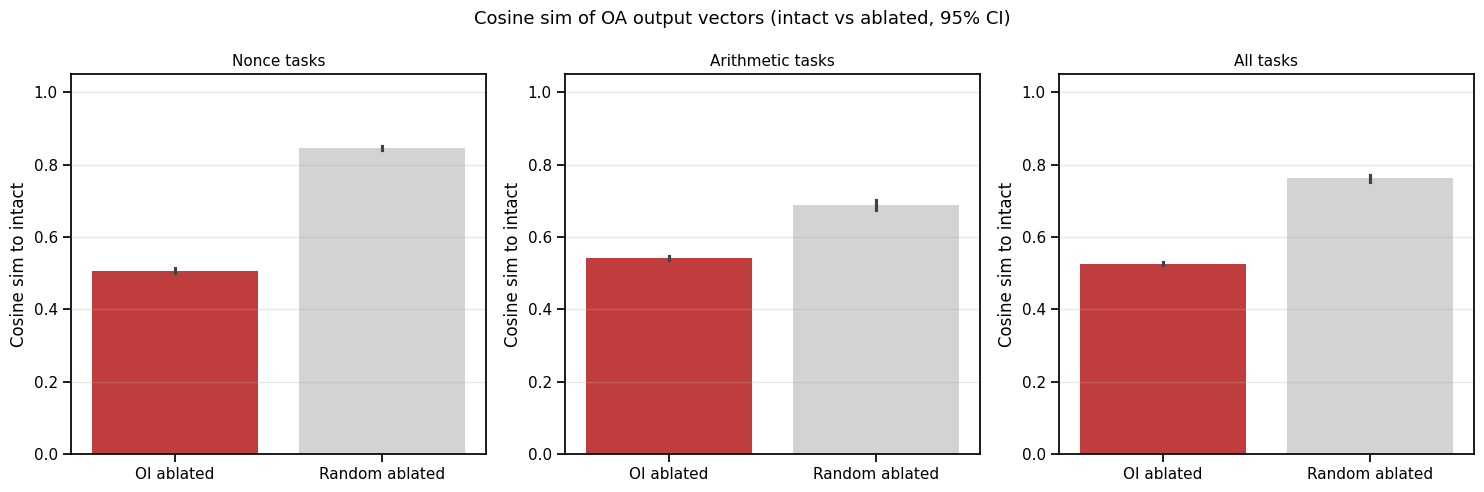


Task                 OI cos  Rand cos     Diff
----------------------------------------------
repetition            0.352     0.678   -0.326
prepend_first         0.554     0.890   -0.336
append_last           0.453     0.811   -0.357
drop_first            0.567     0.881   -0.314
drop_last             0.493     0.894   -0.401
reverse               0.580     0.891   -0.311
swap_ends             0.587     0.889   -0.303
rotate_left           0.577     0.872   -0.295
suffix_ed             0.448     0.839   -0.390
double_vowels         0.585     0.888   -0.303
add_3                 0.473     0.803   -0.330
add_7                 0.443     0.611   -0.167
add_13                0.560     0.544   +0.016
mul_2                 0.492     0.806   -0.314
mul_3                 0.556     0.632   -0.076
mul_5                 0.615     0.757   -0.141
mul_10                0.633     0.745   -0.112
mul_2_add_1           0.550     0.723   -0.173
mul_3_add_2           0.546     0.624   -0.078
mul_2_sub_1 

In [21]:
# === Plot: cosine similarity with control ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    rows = []
    for name in task_list:
        for v in oa_output_cos[name]['oi_ablated']:
            rows.append({'Condition': 'OI ablated', 'Cosine sim to intact': v})
        for v in oa_output_cos[name]['rand_ablated']:
            rows.append({'Condition': 'Random ablated', 'Cosine sim to intact': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Condition', y='Cosine sim to intact',
                palette={'OI ablated': 'tab:red', 'Random ablated': 'lightgray'},
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_title(f'{group_label}', fontsize=11)
    ax.set_xlabel(''); ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
fig.suptitle("Cosine sim of OA output vectors (intact vs ablated, 95% CI)", fontsize=13)
plt.tight_layout(); plt.show()

# Per-task
print(f'\n{"Task":<18s} {"OI cos":>8s} {"Rand cos":>9s} {"Diff":>8s}')
print('-' * 46)
for name in TASK_NAMES_ACTIVE:
    oi_cos = np.mean(oa_output_cos[name]['oi_ablated'])
    rand_cos = np.mean(oa_output_cos[name]['rand_ablated'])
    print(f'{name:<18s} {oi_cos:>8.3f} {rand_cos:>9.3f} {oi_cos - rand_cos:>+8.3f}')

In [22]:
# === Is the OI→OA connection direct or MLP-mediated? ===
# Ablate MLPs in layers between OI and OA, measure accuracy

# Find the gap layers per task
for name in TASK_NAMES_ACTIVE[:3]:
    oi_layers = sorted(set(L for L, h in task_oi_top[name]))
    oa_layers = sorted(set(L for L, h in task_oa_top[name]))
    print(f'{name}: OI layers {oi_layers[:5]}...  OA layers {oa_layers[:5]}...')

# Define gap as layers where OI heads end to where OA heads begin
oi_max = int(np.median([max(L for L, h in task_oi_top[name]) for name in TASK_NAMES_ACTIVE]))
oa_min = int(np.median([min(L for L, h in task_oa_top[name]) for name in TASK_NAMES_ACTIVE]))
gap_layers = list(range(oi_max, oa_min + 1))
print(f'\nMedian OI max layer: {oi_max}, median OA min layer: {oa_min}')
print(f'Gap layers (MLPs to test): {gap_layers}')

# Ablate MLPs in gap layers
def make_mlp_zero_hooks(layers):
    hooks = []
    for L in layers:
        def hook(mlp_out, hook, _L=L):
            mlp_out[:] = 0
            return mlp_out
        hooks.append((f'blocks.{L}.hook_mlp_out', hook))
    return hooks

mlp_hooks = make_mlp_zero_hooks(gap_layers)

ABL_KEYS_MLP = ['unablated', 'gap_mlps_ablated', 'oi_ablated', 'oi_and_gap_mlps']
mlp_results = {name: {k: [] for k in ABL_KEYS_MLP} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oi_hooks = make_ablation_hooks(heads_by_layer(task_oi_top[name]))
    hooks_map = {
        'unablated': [],
        'gap_mlps_ablated': mlp_hooks,
        'oi_ablated': oi_hooks,
        'oi_and_gap_mlps': oi_hooks + mlp_hooks,
    }
    for pdata in tqdm(TASKS[name], desc=f'{name} MLP test'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        for k in ABL_KEYS_MLP:
            h = hooks_map[k] if hooks_map[k] else None
            mlp_results[name][k].append(
                check_correct_multitoken(model, tokens, ans, hooks=h))
        torch.cuda.empty_cache()
    for k in ABL_KEYS_MLP:
        mlp_results[name][k] = np.array(mlp_results[name][k])

print('MLP mediation test complete')

repetition: OI layers [0, 1, 2, 4, 5]...  OA layers [0, 2, 3, 5, 6]...
prepend_first: OI layers [0, 1, 4, 5, 6]...  OA layers [0, 2, 5, 6, 8]...
append_last: OI layers [0, 1, 2, 4, 5]...  OA layers [2, 5, 6, 8, 9]...

Median OI max layer: 24, median OA min layer: 2
Gap layers (MLPs to test): []


mul_2_sub_1 MLP test: 100%|██████████| 50/50 [00:15<00:00,  3.14it/s]

MLP mediation test complete


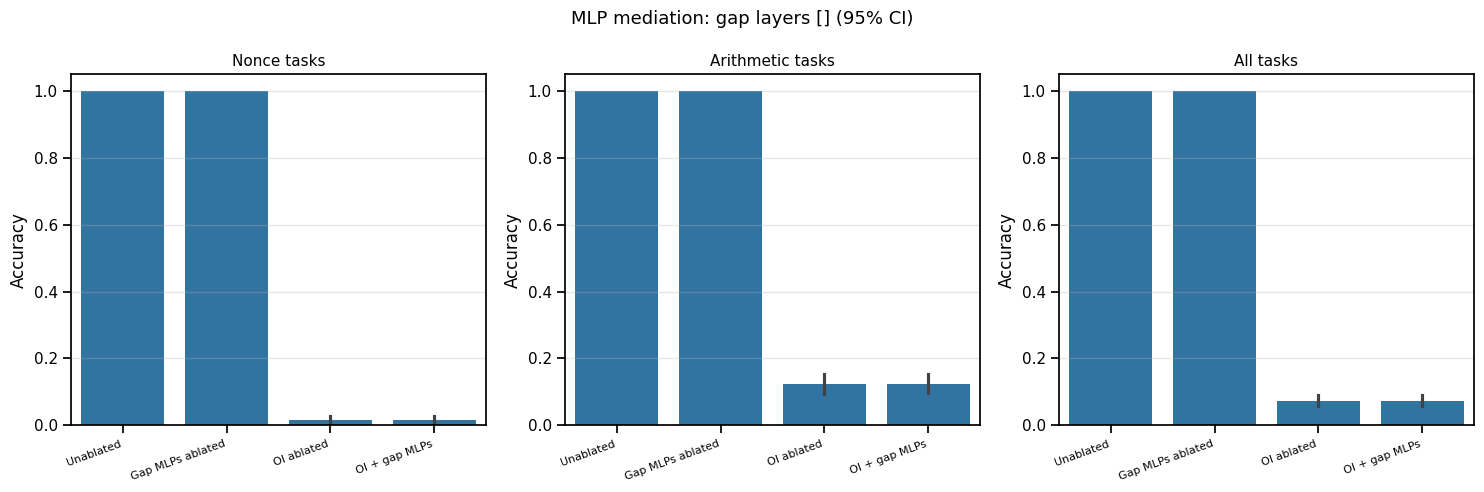

In [23]:
# === Plot MLP mediation ===

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ab_label_mlp = {'unablated': 'Unablated', 'gap_mlps_ablated': 'Gap MLPs ablated',
                'oi_ablated': 'OI ablated', 'oi_and_gap_mlps': 'OI + gap MLPs'}
ab_order_mlp = [ab_label_mlp[k] for k in ABL_KEYS_MLP]

for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    rows = []
    for k in ABL_KEYS_MLP:
        for name in task_list:
            for v in mlp_results[name][k]:
                rows.append({'Ablation': ab_label_mlp[k], 'Accuracy': v})
    df = pd.DataFrame(rows)
    sns.barplot(data=df, x='Ablation', y='Accuracy', order=ab_order_mlp,
                errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel('')
    ax.set_title(f'{group_label}', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
fig.suptitle(f'MLP mediation: gap layers {gap_layers} (95% CI)', fontsize=13)
plt.tight_layout(); plt.show()

OI write → OA read subspace overlap (k=16):
  OI→OA pairs: 0.0092 ± 0.0108
  Random pairs: 0.0050 ± 0.0034


/tmp/ipykernel_134892/2802414750.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pair type', y='Subspace overlap',


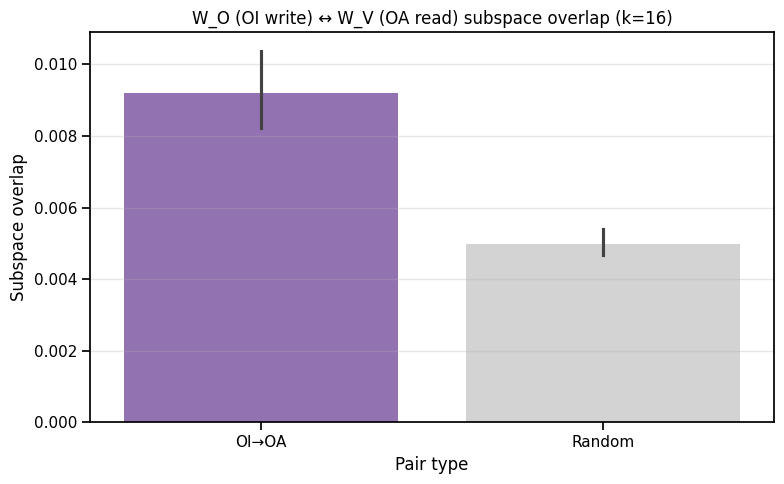

In [24]:
# === Subspace alignment: do OA heads' W_V read from OI heads' W_O write space? ===

def get_write_subspace(model, L, h, k=16):
    """Top-k right singular vectors of W_O (the subspace this head writes into)."""
    W_O = model.blocks[L].attn.W_O[h].detach().cpu().float()  # (d_head, d_model)
    U, S, Vt = torch.linalg.svd(W_O, full_matrices=False)
    return Vt[:k]  # (k, d_model) — top-k directions in residual stream

def get_read_subspace(model, L, h, k=16):
    """Top-k left singular vectors of W_V (the subspace this head reads from)."""
    W_V = model.blocks[L].attn.W_V[h].detach().cpu().float()  # (d_model, d_head)
    U, S, Vt = torch.linalg.svd(W_V, full_matrices=False)
    return U[:, :k].T  # (k, d_model) — top-k directions in residual stream

def subspace_overlap(A, B):
    """Fraction of variance in A captured by B's subspace. A, B are (k, d_model)."""
    # Project A onto B's span
    B_orth, _ = torch.linalg.qr(B.T)  # (d_model, k)
    A_proj = A @ B_orth  # (k_A, k_B)
    return (A_proj.norm()**2 / A.norm()**2).item()

k = 16

# OI→OA alignment: does OA's W_V read from OI's W_O write space?
oi_oa_overlaps = []
for name in TASK_NAMES_ACTIVE:
    for L_oi, h_oi in task_oi_top[name][:5]:  # top 5 OI
        write_sub = get_write_subspace(model, L_oi, h_oi, k=k)
        for L_oa, h_oa in task_oa_top[name][:5]:  # top 5 OA
            if L_oa <= L_oi: continue  # OA must be downstream
            read_sub = get_read_subspace(model, L_oa, h_oa, k=k)
            oi_oa_overlaps.append(subspace_overlap(read_sub, write_sub))

# Control: random head pairs at similar layer gaps
rng_sub = random.Random(42)
rand_overlaps = []
for _ in range(len(oi_oa_overlaps)):
    L1 = rng_sub.randint(0, n_layers // 2)
    L2 = rng_sub.randint(n_layers // 2, n_layers - 1)
    h1 = rng_sub.randint(0, n_heads - 1)
    h2 = rng_sub.randint(0, n_heads - 1)
    write_sub = get_write_subspace(model, L1, h1, k=k)
    read_sub = get_read_subspace(model, L2, h2, k=k)
    rand_overlaps.append(subspace_overlap(read_sub, write_sub))

print(f'OI write → OA read subspace overlap (k={k}):')
print(f'  OI→OA pairs: {np.mean(oi_oa_overlaps):.4f} ± {np.std(oi_oa_overlaps):.4f}')
print(f'  Random pairs: {np.mean(rand_overlaps):.4f} ± {np.std(rand_overlaps):.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
rows = []
for v in oi_oa_overlaps:
    rows.append({'Pair type': 'OI→OA', 'Subspace overlap': v})
for v in rand_overlaps:
    rows.append({'Pair type': 'Random', 'Subspace overlap': v})
df = pd.DataFrame(rows)
sns.barplot(data=df, x='Pair type', y='Subspace overlap',
            palette={'OI→OA': 'tab:purple', 'Random': 'lightgray'},
            errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_title(f'W_O (OI write) ↔ W_V (OA read) subspace overlap (k={k})', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

Collected 71930 OI write vectors, shape (71930, 3072)
Top 16 PCs explain 39.5% variance
Per-PC variance: ['9.8%', '5.3%', '3.9%', '3.3%', '2.8%']

OA heads W_V projection onto OI write subspace:
  OA heads: 0.0071 ± 0.0027
  Random:   0.0049 ± 0.0016


/tmp/ipykernel_134892/1815030465.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Type', y='W_V projection onto OI writes',


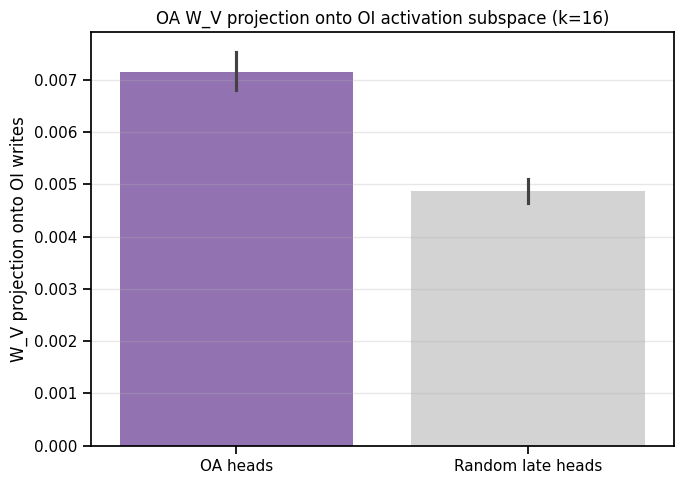

In [25]:
# === Activation-grounded subspace alignment ===
# 1. Collect what OI heads ACTUALLY write at output positions across prompts
# 2. PCA to find the subspace OI heads use in practice
# 3. Check if OA heads' W_V has high projection onto that subspace

from sklearn.decomposition import PCA

Z_FILTER = lambda name: 'attn.hook_z' in name
k_pca = 16

# Step 1: Collect OI head outputs at output positions
oi_writes = []  # list of (d_model,) vectors

for name in TASK_NAMES_ACTIVE:
    for pdata in tqdm(TASKS[name][:20], desc=f'{name} OI writes', leave=False):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        out_positions = sorted(set(p for d in per_demo for p in d.get('output_positions', [])))
        if not out_positions: continue

        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=Z_FILTER)

        for L, h in task_oi_top[name][:10]:
            W_O = model.blocks[L].attn.W_O[h].detach().cpu().float()  # (d_head, d_model)
            for pos in out_positions:
                z = cache[f'blocks.{L}.attn.hook_z'][0, pos, h].cpu().float()  # (d_head,)
                oi_writes.append((z @ W_O).numpy())  # (d_model,)

        del cache; torch.cuda.empty_cache()

oi_writes = np.array(oi_writes)
print(f'Collected {oi_writes.shape[0]} OI write vectors, shape {oi_writes.shape}')

# Step 2: PCA on OI writes
pca = PCA(n_components=k_pca)
pca.fit(oi_writes)
oi_subspace = torch.tensor(pca.components_, dtype=torch.float32)  # (k, d_model)
print(f'Top {k_pca} PCs explain {pca.explained_variance_ratio_.sum()*100:.1f}% variance')
print(f'Per-PC variance: {[f"{v*100:.1f}%" for v in pca.explained_variance_ratio_[:5]]}')

# Step 3: How much does each OA head's W_V project onto OI write subspace?
oi_sub_orth, _ = torch.linalg.qr(oi_subspace.T)  # (d_model, k)

oa_projections = []
rand_projections = []
rng_sub = random.Random(42)

for name in TASK_NAMES_ACTIVE:
    for L, h in task_oa_top[name][:10]:
        W_V = model.blocks[L].attn.W_V[h].detach().cpu().float()  # (d_model, d_head)
        # Fraction of W_V's Frobenius norm in the OI subspace
        proj = W_V.T @ oi_sub_orth  # (d_head, k)
        frac = (proj.norm()**2 / W_V.norm()**2).item()
        oa_projections.append(frac)

# Control: random heads at similar layers
for _ in range(len(oa_projections)):
    L = rng_sub.randint(n_layers // 2, n_layers - 1)
    h = rng_sub.randint(0, n_heads - 1)
    W_V = model.blocks[L].attn.W_V[h].detach().cpu().float()
    proj = W_V.T @ oi_sub_orth
    frac = (proj.norm()**2 / W_V.norm()**2).item()
    rand_projections.append(frac)

print(f'\nOA heads W_V projection onto OI write subspace:')
print(f'  OA heads: {np.mean(oa_projections):.4f} ± {np.std(oa_projections):.4f}')
print(f'  Random:   {np.mean(rand_projections):.4f} ± {np.std(rand_projections):.4f}')

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
rows = []
for v in oa_projections:
    rows.append({'Type': 'OA heads', 'W_V projection onto OI writes': v})
for v in rand_projections:
    rows.append({'Type': 'Random late heads', 'W_V projection onto OI writes': v})
df = pd.DataFrame(rows)
sns.barplot(data=df, x='Type', y='W_V projection onto OI writes',
            palette={'OA heads': 'tab:purple', 'Random late heads': 'lightgray'},
            errorbar=('ci', 95), linewidth=0, ax=ax)
ax.set_title(f'OA W_V projection onto OI activation subspace (k={k_pca})', fontsize=12)
ax.set_xlabel(''); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

OA W_V pairwise overlap: 0.1417 ± 0.1200 (n=105 pairs from 15 heads)
Random W_V pairwise:     0.1246 ± 0.0096
OI W_O pairwise overlap: 0.0163 ± 0.0326 (n=231 pairs from 22 heads)
Random W_O pairwise:     0.0078 ± 0.0094


/tmp/ipykernel_134892/1293427095.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Type', y='Pairwise overlap',
/tmp/ipykernel_134892/1293427095.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Type', y='Pairwise overlap',


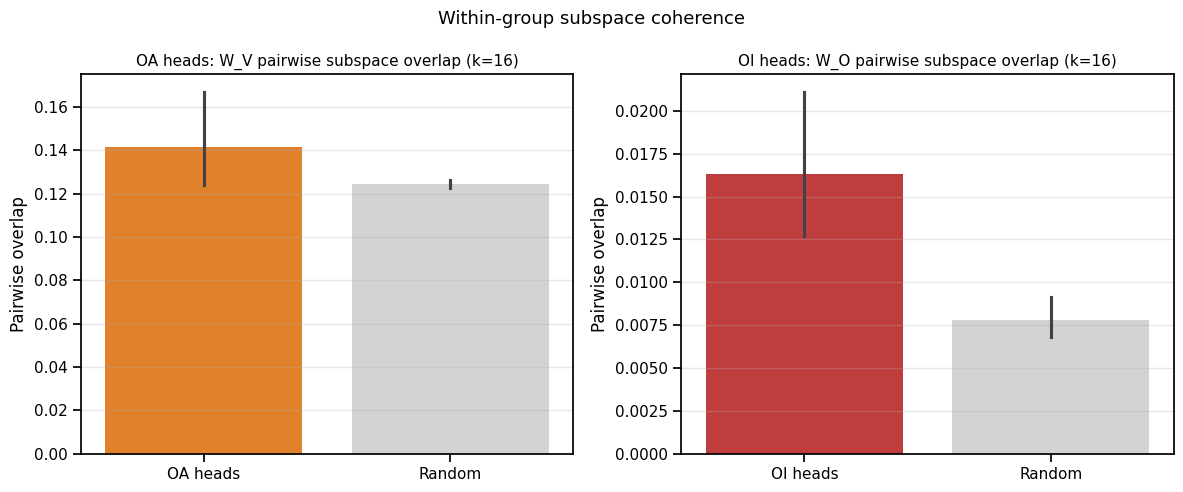

In [26]:
# === Within-group coherence: do OA heads read from a shared subspace? Do OI heads write to one? ===

def pairwise_subspace_overlap(matrices, k=16):
    """Compute pairwise subspace overlap among a list of matrices."""
    subspaces = []
    for M in matrices:
        U, S, Vt = torch.linalg.svd(M, full_matrices=False)
        subspaces.append(Vt[:k])  # top-k right singular vectors
    
    overlaps = []
    for i in range(len(subspaces)):
        for j in range(i+1, len(subspaces)):
            overlaps.append(subspace_overlap(subspaces[i], subspaces[j]))
    return overlaps

k = 16

# OA W_V pairwise alignment (do OA heads read from similar directions?)
oa_Wv_matrices = []
oa_head_ids = set()
for name in TASK_NAMES_ACTIVE:
    for L, h in task_oa_top[name][:5]:
        if (L, h) not in oa_head_ids:
            oa_head_ids.add((L, h))
            W_V = model.blocks[L].attn.W_V[h].detach().cpu().float()
            oa_Wv_matrices.append(W_V)

# OI W_O pairwise alignment (do OI heads write to similar directions?)
oi_Wo_matrices = []
oi_head_ids = set()
for name in TASK_NAMES_ACTIVE:
    for L, h in task_oi_top[name][:5]:
        if (L, h) not in oi_head_ids:
            oi_head_ids.add((L, h))
            W_O = model.blocks[L].attn.W_O[h].detach().cpu().float()  # (d_head, d_model)
            oi_Wo_matrices.append(W_O)

# Random heads for control
rng_c = random.Random(99)
rand_matrices_v = []
rand_matrices_o = []
for _ in range(max(len(oa_Wv_matrices), len(oi_Wo_matrices))):
    L = rng_c.randint(0, n_layers - 1)
    h = rng_c.randint(0, n_heads - 1)
    rand_matrices_v.append(model.blocks[L].attn.W_V[h].detach().cpu().float())
    rand_matrices_o.append(model.blocks[L].attn.W_O[h].detach().cpu().float())

oa_wv_pairs = pairwise_subspace_overlap(oa_Wv_matrices, k=k)
oi_wo_pairs = pairwise_subspace_overlap(oi_Wo_matrices, k=k)
rand_wv_pairs = pairwise_subspace_overlap(rand_matrices_v[:len(oa_Wv_matrices)], k=k)
rand_wo_pairs = pairwise_subspace_overlap(rand_matrices_o[:len(oi_Wo_matrices)], k=k)

print(f'OA W_V pairwise overlap: {np.mean(oa_wv_pairs):.4f} ± {np.std(oa_wv_pairs):.4f} '
      f'(n={len(oa_wv_pairs)} pairs from {len(oa_Wv_matrices)} heads)')
print(f'Random W_V pairwise:     {np.mean(rand_wv_pairs):.4f} ± {np.std(rand_wv_pairs):.4f}')
print(f'OI W_O pairwise overlap: {np.mean(oi_wo_pairs):.4f} ± {np.std(oi_wo_pairs):.4f} '
      f'(n={len(oi_wo_pairs)} pairs from {len(oi_Wo_matrices)} heads)')
print(f'Random W_O pairwise:     {np.mean(rand_wo_pairs):.4f} ± {np.std(rand_wo_pairs):.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

rows = []
for v in oa_wv_pairs: rows.append({'Type': 'OA heads', 'Pairwise overlap': v})
for v in rand_wv_pairs: rows.append({'Type': 'Random', 'Pairwise overlap': v})
df = pd.DataFrame(rows)
sns.barplot(data=df, x='Type', y='Pairwise overlap',
            palette={'OA heads': 'tab:orange', 'Random': 'lightgray'},
            errorbar=('ci', 95), linewidth=0, ax=axes[0])
axes[0].set_title(f'OA heads: W_V pairwise subspace overlap (k={k})', fontsize=11)
axes[0].set_xlabel(''); axes[0].grid(True, alpha=0.3, axis='y')

rows = []
for v in oi_wo_pairs: rows.append({'Type': 'OI heads', 'Pairwise overlap': v})
for v in rand_wo_pairs: rows.append({'Type': 'Random', 'Pairwise overlap': v})
df = pd.DataFrame(rows)
sns.barplot(data=df, x='Type', y='Pairwise overlap',
            palette={'OI heads': 'tab:red', 'Random': 'lightgray'},
            errorbar=('ci', 95), linewidth=0, ax=axes[1])
axes[1].set_title(f'OI heads: W_O pairwise subspace overlap (k={k})', fontsize=11)
axes[1].set_xlabel(''); axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Within-group subspace coherence', fontsize=13)
plt.tight_layout(); plt.show()

In [41]:
# === Pathway layer sweep with random controls ===

test_layers = list(range(0, n_layers))
pos_types = ['output_pos', 'final_pos', 'input_pos', 'query_pos']

damage_oi   = {name: {p: np.zeros(n_layers) for p in pos_types} for name in TASK_NAMES_ACTIVE}
damage_rand = {name: {p: np.zeros(n_layers) for p in pos_types} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oi_hooks = make_ablation_hooks(heads_by_layer(task_oi_top[name]))

    oi_set = set(task_oi_top[name])
    oa_set = set(task_oa_top[name])
    rng_r = random.Random(hash(name + '_sweep_ctrl') % 10**6)
    rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set and p not in oa_set],
                               top10pct_n)
    rand_hooks = make_ablation_hooks(heads_by_layer(rand_heads))

    for pdata in tqdm(TASKS[name], desc=f'{name} sweep'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        out_pos = sorted(set(p for d in per_demo for p in d.get('output_positions', [])))
        in_pos = sorted(set(p for d in per_demo for p in d.get('input_positions', [])))
        final_pos = [seq_len - 1]

        query_str = str(pdata['query_input'])
        full_decoded = model.tokenizer.decode(model.to_tokens(pdata['prompt'], prepend_bos=True)[0])
        last_arrow = full_decoded.rfind('\u2192')
        query_idx = full_decoded.rfind(query_str, 0, last_arrow)
        if query_idx >= 0:
            char_to_tok = []
            toks = model.to_tokens(pdata['prompt'], prepend_bos=True)[0]
            for i in range(len(toks)):
                s = model.tokenizer.decode([toks[i].item()])
                char_to_tok.extend([i] * len(s))
            q_pos = sorted(set(char_to_tok[ci] for ci in range(query_idx,
                           min(query_idx + len(query_str), len(char_to_tok)))))
        else:
            q_pos = []

        pos_map = {'output_pos': out_pos, 'final_pos': final_pos,
                   'input_pos': in_pos, 'query_pos': q_pos}

        intact_acc = check_correct_multitoken(model, tokens, ans)

        # Cache OI-ablated and random-ablated residuals at all layers
        for abl_label, abl_hooks, damage_dict in [
            ('oi', oi_hooks, damage_oi),
            ('rand', rand_hooks, damage_rand)]:

            abl_resids = {}
            cache_hooks = []
            for L in test_layers:
                def make_cacher(layer):
                    def hook_fn(resid, hook):
                        abl_resids[layer] = resid.detach().clone()
                        return resid
                    return hook_fn
                cache_hooks.append((f'blocks.{L}.hook_resid_post', make_cacher(L)))

            with torch.no_grad():
                model.run_with_hooks(tokens, fwd_hooks=list(abl_hooks) + cache_hooks)

            for L in test_layers:
                abl_r = abl_resids[L]
                for pos_name, positions in pos_map.items():
                    if not positions: continue
                    def make_hook(pos_list, abl_resid):
                        def hook_fn(resid, hook):
                            for p in pos_list:
                                resid[0, p, :] = abl_resid[0, p, :]
                            return resid
                        return hook_fn
                    h = [(f'blocks.{L}.hook_resid_post', make_hook(positions, abl_r))]
                    acc = check_correct_multitoken(model, tokens, ans, hooks=h)
                    damage_dict[name][pos_name][L] += (intact_acc - acc)

            del abl_resids

        torch.cuda.empty_cache()

    n_prompts = len(TASKS[name])
    for k in pos_types:
        damage_oi[name][k] /= n_prompts
        damage_rand[name][k] /= n_prompts

print('Layer sweep with controls complete')

repetition sweep:  24%|██▍       | 12/50 [10:31<33:19, 52.62s/it]


KeyboardInterrupt: 

: 

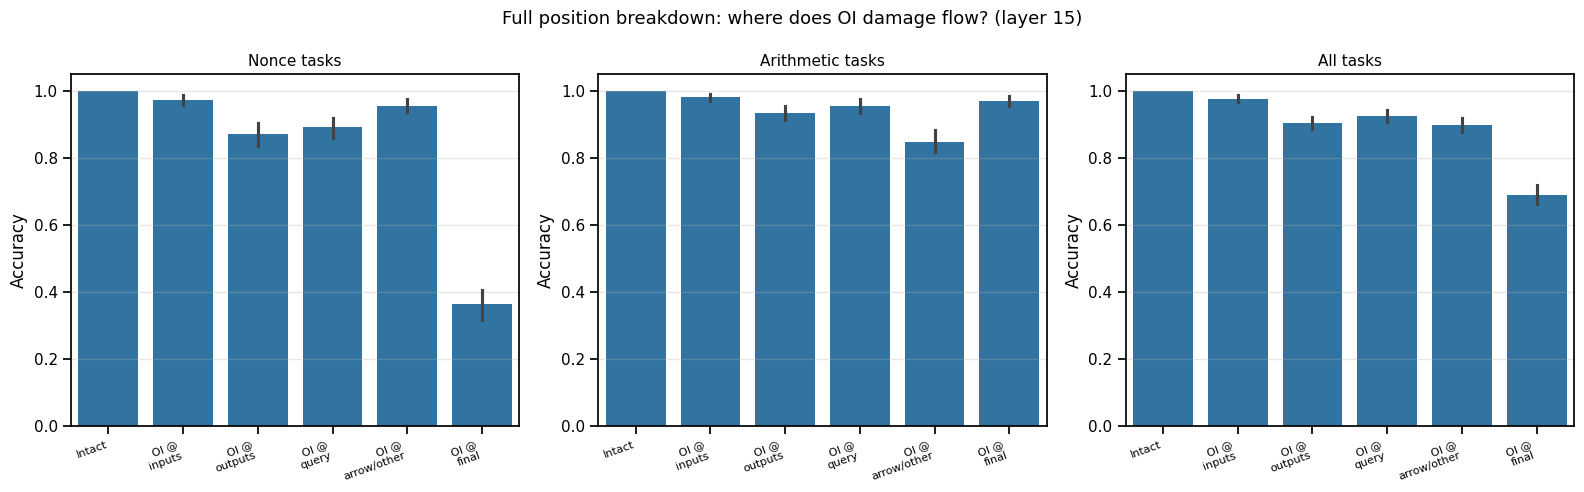

In [ ]:
# === Plot: specific damage = OI damage - random damage, by position type across layers ===
layers = np.arange(n_layers)
pos_colors = {'output_pos': 'tab:green', 'final_pos': 'tab:red',
              'input_pos': 'tab:blue', 'query_pos': 'tab:purple'}
pos_labels = {'output_pos': 'Output positions', 'final_pos': 'Final position',
              'input_pos': 'Input positions', 'query_pos': 'Query position'}

# Raw damage: OI and random side by side
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, (group_label, task_list) in enumerate([
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    for row, (abl_label, damage_dict) in enumerate([('OI ablation', damage_oi),
                                                      ('Random ablation', damage_rand)]):
        ax = axes[row, col]
        for pos_type in pos_types:
            stacked = np.array([damage_dict[name][pos_type] for name in task_list])
            mean_damage = stacked.mean(axis=0)
            se = stacked.std(axis=0) / np.sqrt(len(task_list))
            ax.plot(layers, mean_damage, color=pos_colors[pos_type],
                    label=pos_labels[pos_type], lw=1.5)
            ax.fill_between(layers, mean_damage - 1.96*se, mean_damage + 1.96*se,
                            color=pos_colors[pos_type], alpha=0.15)
        ax.set_xlabel('Layer'); ax.set_ylabel('Accuracy drop')
        ax.set_title(f'{group_label} — {abl_label}', fontsize=10)
        ax.grid(True, alpha=0.3); ax.axhline(0, color='black', lw=0.5)
        if col == 0 and row == 0: ax.legend(fontsize=7)
fig.suptitle('Raw damage by position type across layers (top: OI, bottom: random)', fontsize=13)
plt.tight_layout(); plt.show()

# Specific damage: OI minus random
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    for pos_type in pos_types:
        oi_stacked = np.array([damage_oi[name][pos_type] for name in task_list])
        rand_stacked = np.array([damage_rand[name][pos_type] for name in task_list])
        specific = oi_stacked - rand_stacked
        mean_spec = specific.mean(axis=0)
        se = specific.std(axis=0) / np.sqrt(len(task_list))
        ax.plot(layers, mean_spec, color=pos_colors[pos_type],
                label=pos_labels[pos_type], lw=1.5)
        ax.fill_between(layers, mean_spec - 1.96*se, mean_spec + 1.96*se,
                        color=pos_colors[pos_type], alpha=0.15)
    ax.set_xlabel('Layer'); ax.set_ylabel('Specific damage (OI \u2212 random)')
    ax.set_title(f'{group_label}', fontsize=11)
    ax.grid(True, alpha=0.3); ax.axhline(0, color='black', lw=0.5)
axes[0].legend(fontsize=8)
fig.suptitle('OI-specific damage by position type across layers (OI minus random control)', fontsize=13)
plt.tight_layout(); plt.show()

In [39]:
# === Slot-aggregated attention patterns for top OI and OA heads ===
# Separately for nonce, arithmetic, and all tasks

n_demos_assumed = 10
slot_labels = ['BOS']
for d in range(n_demos_assumed):
    slot_labels += [f'in_{d}', f'arr_{d}', f'out_{d}']
slot_labels += ['q_in', 'q_arr']
n_slots = len(slot_labels)
slot_idx = {s: i for i, s in enumerate(slot_labels)}

def position_to_slot(pos, per_demo, seq_len):
    if pos == 0: return 'BOS'
    for d_idx, d in enumerate(per_demo):
        ins  = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        if pos in ins:  return f'in_{d_idx}'
        if pos in outs: return f'out_{d_idx}'
        if ins and outs and (max(ins) < pos < min(outs)): return f'arr_{d_idx}'
    last_demo = per_demo[-1]
    last_out = max(last_demo.get('output_positions', [0]))
    if pos > last_out:
        if pos == seq_len - 1: return 'q_arr'
        return 'q_in'
    return None

# Pool top OI and OA heads across all tasks
oi_pooled_scores = np.mean([task_oi_scores[n] for n in TASK_NAMES_ACTIVE], axis=0)
oa_pooled_scores = np.mean([task_oa_scores[n] for n in TASK_NAMES_ACTIVE], axis=0)
oi_flat = sorted([(L, h, oi_pooled_scores[L, h]) for L in range(n_layers) for h in range(n_heads)],
                 key=lambda x: -x[2])
oa_flat = sorted([(L, h, oa_pooled_scores[L, h]) for L in range(n_layers) for h in range(n_heads)],
                 key=lambda x: -x[2])
top_oi = [(L, h) for L, h, _ in oi_flat[:9]]
top_oa = [(L, h) for L, h, _ in oa_flat[:9]]
all_heads = list(set(top_oi + top_oa))

groups = {
    'Nonce': nonce_active,
    'Arithmetic': arith_active,
    'All': TASK_NAMES_ACTIVE,
}

group_patterns = {}  # {group: {(L,h): (n_slots, n_slots) array}}

for group_name, task_list in groups.items():
    agg_sum = {(L, h): np.zeros((n_slots, n_slots), dtype=np.float64) for L, h in all_heads}
    agg_cnt = {(L, h): np.zeros((n_slots, n_slots), dtype=np.int64) for L, h in all_heads}

    total = 0
    for name in task_list:
        for pdata in tqdm(TASKS[name], desc=f'{group_name}/{name}', leave=False):
            demos = pdata['demo_pairs']
            if len(demos) != n_demos_assumed: continue
            tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
            seq_len = tokens.shape[1]
            per_demo = find_per_demo_positions(model, pdata['prompt'], demos)

            pos_slot_arr = np.full(seq_len, -1, dtype=np.int64)
            for pos in range(seq_len):
                s = position_to_slot(pos, per_demo, seq_len)
                if s is not None:
                    pos_slot_arr[pos] = slot_idx[s]

            valid = pos_slot_arr >= 0
            if not valid.any(): continue

            q_idx, k_idx = np.meshgrid(np.arange(seq_len), np.arange(seq_len), indexing='ij')
            causal_mask = (q_idx >= k_idx) & valid[q_idx] & valid[k_idx]
            q_slot_grid = np.where(causal_mask, pos_slot_arr[q_idx], -1)
            k_slot_grid = np.where(causal_mask, pos_slot_arr[k_idx], -1)
            flat_slot_idx = q_slot_grid * n_slots + k_slot_grid
            flat_valid = causal_mask

            counts_flat = np.bincount(flat_slot_idx[flat_valid], minlength=n_slots * n_slots)
            slot_cnt = counts_flat.reshape(n_slots, n_slots)

            with torch.no_grad():
                _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)

            for L, h in all_heads:
                patt = cache['pattern', L][0, h].cpu().float().numpy()
                sums_flat = np.bincount(
                    flat_slot_idx[flat_valid],
                    weights=patt[flat_valid],
                    minlength=n_slots * n_slots,
                )
                slot_sum = sums_flat.reshape(n_slots, n_slots)
                with np.errstate(invalid='ignore', divide='ignore'):
                    slot_avg = np.where(slot_cnt > 0, slot_sum / slot_cnt, 0.0)
                agg_sum[(L, h)] += slot_avg
                agg_cnt[(L, h)] += (slot_cnt > 0).astype(np.int64)

            total += 1
            del cache; torch.cuda.empty_cache()

    patterns = {}
    for L, h in all_heads:
        with np.errstate(invalid='ignore', divide='ignore'):
            patterns[(L, h)] = np.where(agg_cnt[(L, h)] > 0,
                                         agg_sum[(L, h)] / agg_cnt[(L, h)], 0.0)
    group_patterns[group_name] = patterns
    print(f'{group_name}: averaged over {total} prompts')

print('Done')

Nonce: averaged over 417 prompts


Arithmetic: averaged over 485 prompts


All: averaged over 902 prompts
Done


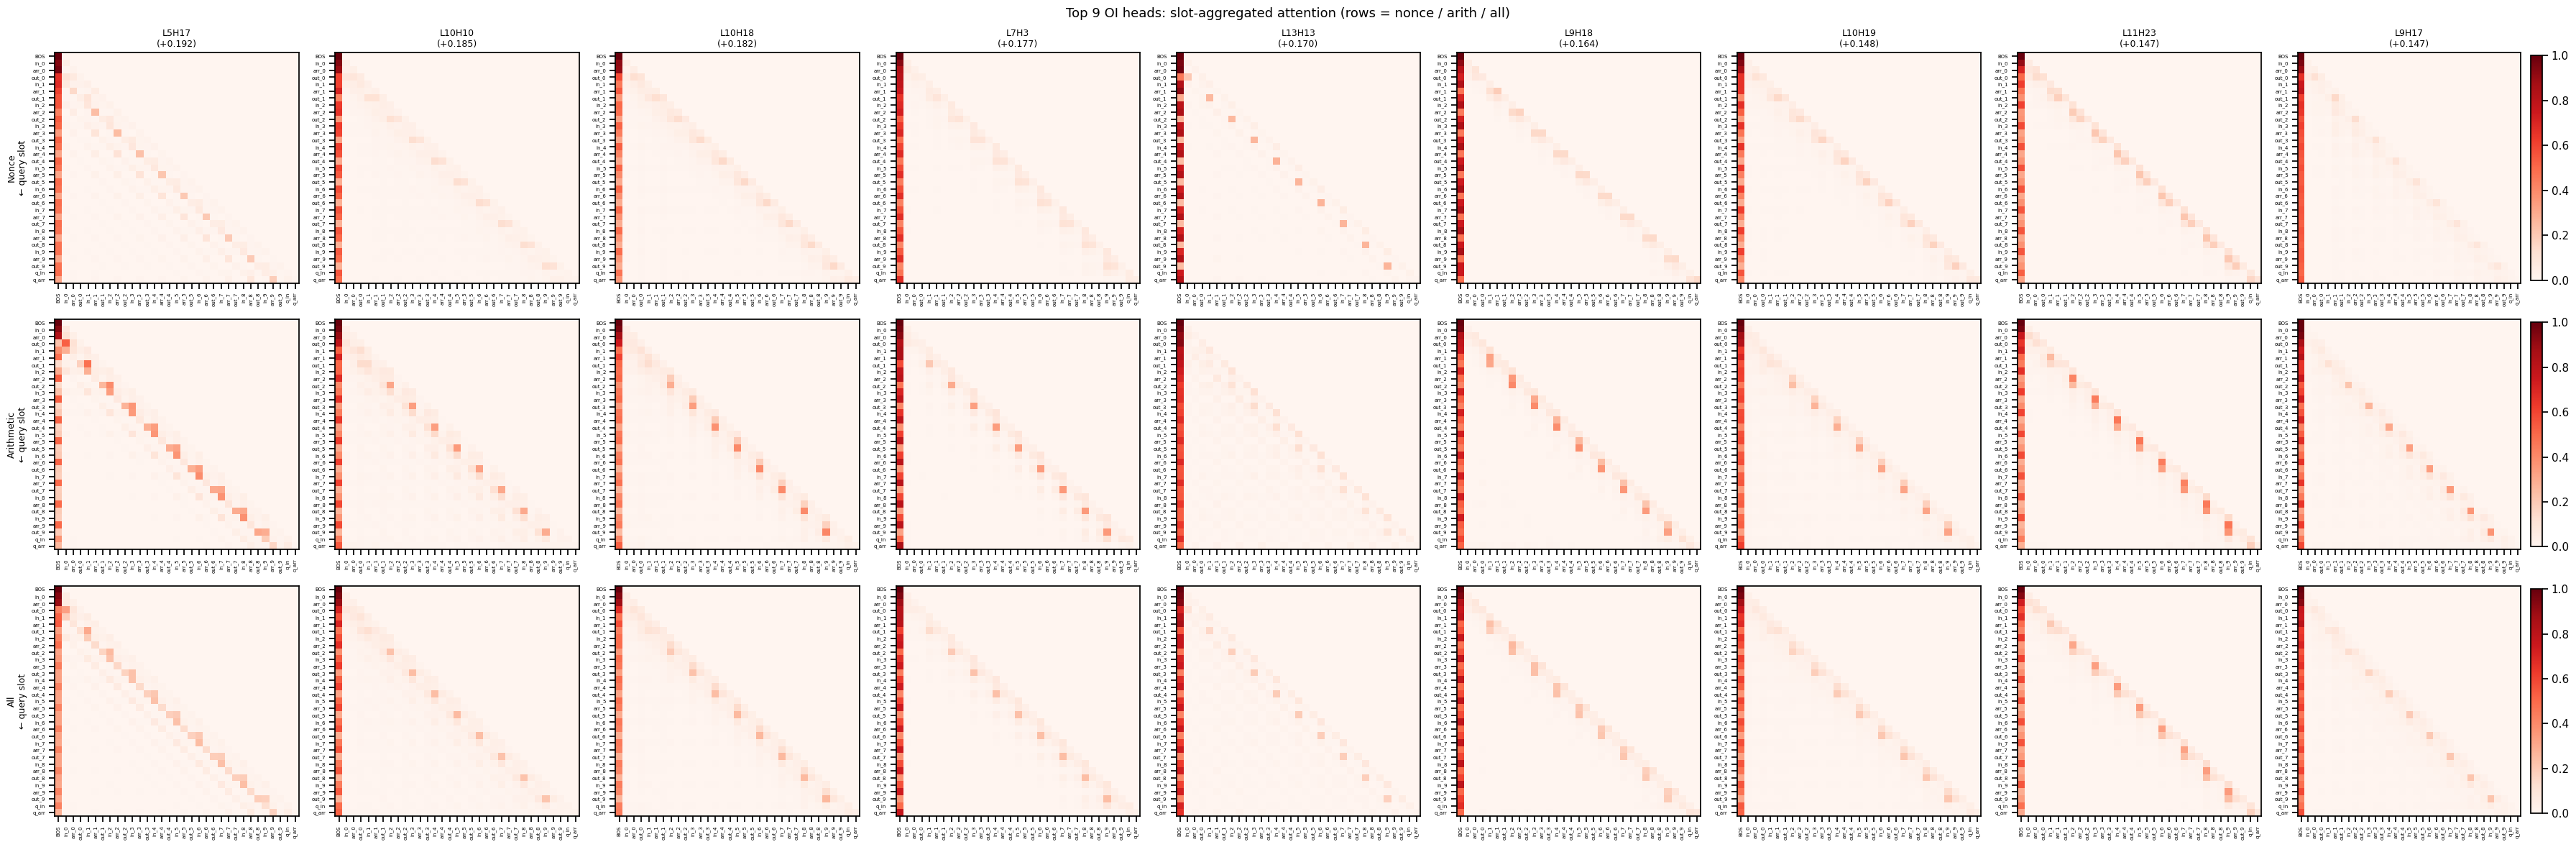

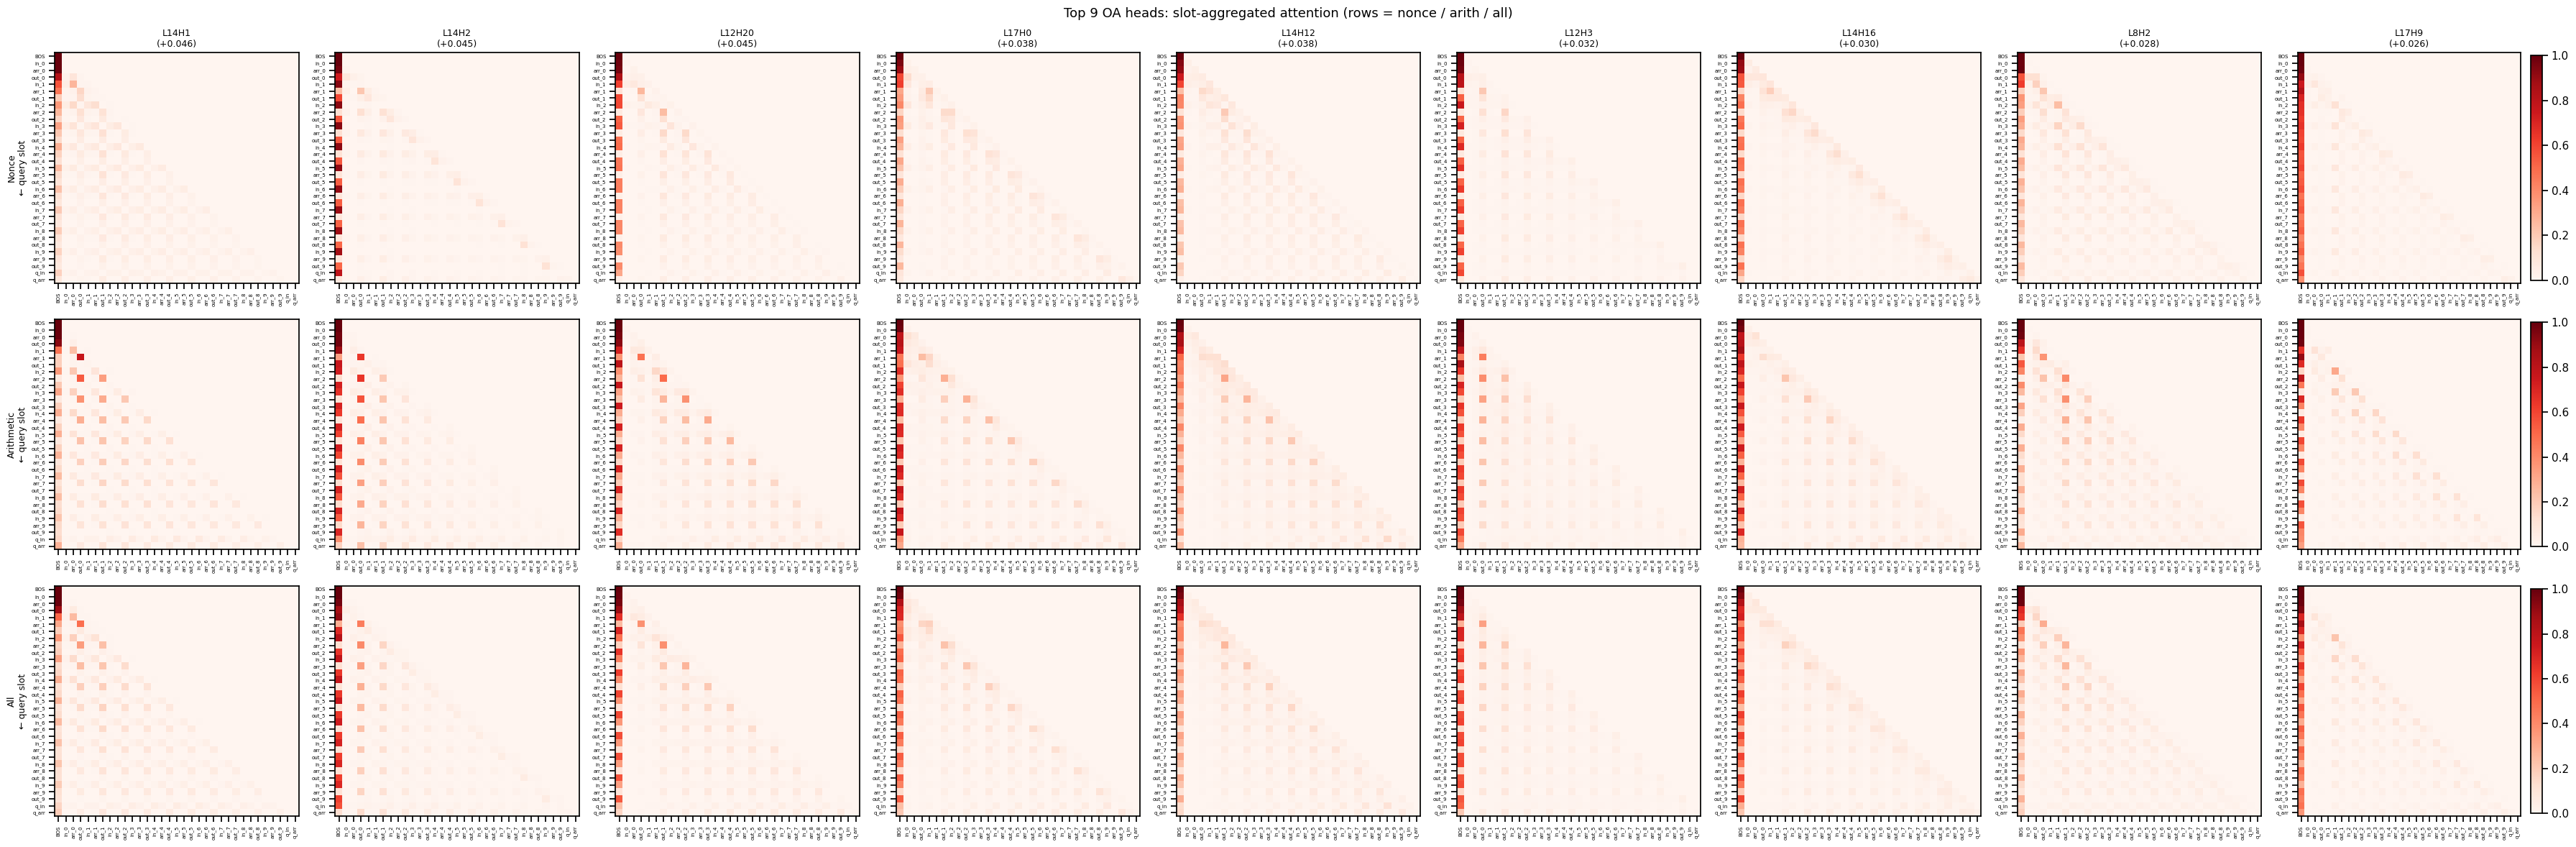

In [40]:
# === Plot: top OI heads, one row per group ===
for head_type, heads_list, scores in [('OI', top_oi, oi_pooled_scores),
                                       ('OA', top_oa, oa_pooled_scores)]:
    fig, axes = plt.subplots(3, len(heads_list), figsize=(4*len(heads_list), 12))

    for row, group_name in enumerate(['Nonce', 'Arithmetic', 'All']):
        for col, (L, h) in enumerate(heads_list):
            ax = axes[row, col]
            pat = group_patterns[group_name][(L, h)]
            im = ax.imshow(pat, aspect='auto', cmap='Reds', origin='upper', vmin=0)
            if col == len(heads_list) - 1:
                plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            if row == 0:
                ax.set_title(f'L{L}H{h}\n({scores[L,h]:+.3f})', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'{group_name}\n← query slot', fontsize=9)
            ax.set_xticks(range(n_slots))
            ax.set_xticklabels(slot_labels, rotation=90, fontsize=5)
            ax.set_yticks(range(n_slots))
            ax.set_yticklabels(slot_labels, fontsize=5)

    fig.suptitle(f'Top {len(heads_list)} {head_type} heads: slot-aggregated attention '
                 f'(rows = nonce / arith / all)', fontsize=13)
    plt.tight_layout(); plt.show()